# Se tuvo que hacer una corrección del entregable anterior, ya que no termine de relacionar la tabla de fact sales con las demás, así que en este entregable haré algunas correcciones que creo pertinentes

# Lo primero que hacemos es cargar los datos de todas las tabals con sus modificaciones de la primera tarea

In [17]:
# Lo primero que hacemos es importar las tablas de valores que vamos a utilizar
import pandas as pd

calendar = pd.read_csv("DIM_CALENDAR.csv")
product = pd.read_csv("DIM_PRODUCT.csv")
segment = pd.read_csv("DIM_SEGMENT.csv")
sales = pd.read_csv("FACT_SALES.csv")

In [19]:
# Checamos que ambas tablas se pueden ver 
# Cambiamos el nombre de CODIGO_ARTÍCULO a solo ARTICULO para poder enlazar las tablas posteriormente
sales = sales.rename(columns={'CODIGO_ARTÍCULO': 'ARTICULO'})

# Ventas
sales

,SEMANA,ARTICULO,VENTAS UNIDADES TOTALES,VALORES VENTAS TOTALES,VENTAS SEMANALES PROMEDIO TOTAL POR UNIDAD,REGION
0,26-23,7501058784346,1.468,301.973,2.068,TOTAL AUTOS SCANNING MEXICO
1,44-22,7891035040276,47.708,601.450,21.945,TOTAL AUTOS SCANNING MEXICO
2,24-23,7501025402051,59.381,2058.481,25.885,TOTAL AUTOS SCANNING MEXICO
3,34-22,7501025401917,1.546,103.681,2.944,TOTAL AUTOS SCANNING MEXICO
4,34-22,7501025401887,0.562,12.737,3.193,TOTAL AUTOS SCANNING MEXICO
...,...,...,...,...,...,...
121997,13-23,7501080900141,0.886,63.297,2.524,TOTAL AUTOS AREA 1
121998,13-23,741120000005,0.077,0.866,19.250,TOTAL AUTOS AREA 1
121999,13-22,7501058784353,1.039,77.696,3.463,TOTAL AUTOS AREA 1
122000,13-23,741120000036,0.017,0.298,17.000,TOTAL AUTOS AREA 1


In [21]:
# tipos
segment

,CATEGORIA,ATRIBUTO_1,ATRIBUTO_2,ATRIBUTO_3,PRESENTACION,SEGMENTO
0,1,CLORO,CLORO,BAMBINO,LIQUIDO,LEJÍA
1,1,CLORO,CLORO,GERMICIDA,LIQUIDO,LEJÍA
2,1,CLORO,CLORO,MASCOTAS,LIQUIDO,LEJÍA
3,1,CLORO,CLORO,MULTIUSOS,GEL,LEJÍA
4,1,CLORO,CLORO,MULTIUSOS,LIQUIDO,LEJÍA
5,1,CLORO,CLORO,NO DEFINIDO,LIQUIDO,LEJÍA
6,1,CLORO,CLORO,NO DEFINIDO,POLVO,LEJÍA
7,1,CLORO,CLORO,OTR. TIPOS,LIQUIDO,LEJÍA
8,1,CLORO,CLORO,OTR. TIPOS,POLVO,LEJÍA
9,1,CLORO,CLORO,ROPA BEBE,LIQUIDO,LEJÍA


In [23]:
# Porducto
product

,FABRICANTE,MARCA,ARTICULO,DESCRIPCION_ARTICULO,CATEGORIA,PRESENTACION,ATRIBUTO_1,ATRIBUTO_2,ATRIBUTO_3
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,INDS. ALEN,CLORALEX,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
3,INDS. ALEN,CLORALEX,0000075000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
4,INDS. ALEN,CLORALEX,0000075000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
...,...,...,...,...,...,...,...,...,...
500,RECKITT,VANISH,7501058789778BP1,VANISH EXT HIGIENE REM MANCHAS GAL 4LT + VANIS...,1,LIQUIDO,LEJÍA SEGURA,TRATAMIENTO DEL TEJIDO,ROSA
501,INDS. ALEN,CLORALEX,7501025412142,CLORALEX AROMAS BLANQUEADOR C/AROMA LAVANDA GA...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
502,INDS. ALEN,CLORALEX,NO VALIDO,CLORALEX EL RENDIDOR BOT PLAST 2LT,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
503,CLOROX,CLOROX,NO VALIDO,CLOROX MASCOTAS BLANQUEADOR+DETERGENTE GALON 10L,1,LIQUIDO,CLORO,CLORO,MASCOTAS


In [25]:
# Calendario
calendar

,SEMANA,AÑO,MES,# SEMANA,FECHA
0,01-21,2021,1,1,2021-01-10
1,02-21,2021,1,2,2021-01-17
2,03-21,2021,1,3,2021-01-24
3,04-21,2021,1,4,2021-01-31
4,05-21,2021,2,5,2021-02-07
...,...,...,...,...,...
151,48-23,2023,12,48,2023-12-04
152,49-23,2023,12,49,2023-12-11
153,50-23,2023,12,50,2023-12-18
154,51-23,2023,12,51,2023-12-25


# Hacemos algunas uniones de tablas dependiedo de las tablas, en este caso primero uniremos la tabla calendar con la tabla sales y la tabla segment con product para que se rellenen los campos faltantes 

In [28]:
# Unión de calendar y sales
union1 = pd.merge(sales, calendar, on='SEMANA', how='inner')  
# Organizamos las columnas
orden_columnas = ['ARTICULO', 'VENTAS UNIDADES TOTALES', 'VALORES VENTAS TOTALES', 'VENTAS SEMANALES PROMEDIO TOTAL POR UNIDAD',
                  'REGION','FECHA', 'SEMANA', '# SEMANA', 'MES', 'AÑO'] 
nuevo_sales = union1[orden_columnas]
# guardamos esta nueva tabla 
nuevo_sales.to_csv('nuevo_sales.csv', index=False)
nuevo_sales

,ARTICULO,VENTAS UNIDADES TOTALES,VALORES VENTAS TOTALES,VENTAS SEMANALES PROMEDIO TOTAL POR UNIDAD,REGION,FECHA,SEMANA,# SEMANA,MES,AÑO
0,7501058784346,1.468,301.973,2.068,TOTAL AUTOS SCANNING MEXICO,2023-07-03,26-23,26,7,2023
1,7891035040276,47.708,601.450,21.945,TOTAL AUTOS SCANNING MEXICO,2022-11-06,44-22,44,11,2022
2,7501025402051,59.381,2058.481,25.885,TOTAL AUTOS SCANNING MEXICO,2023-06-19,24-23,24,6,2023
3,7501025401917,1.546,103.681,2.944,TOTAL AUTOS SCANNING MEXICO,2022-08-28,34-22,34,8,2022
4,7501025401887,0.562,12.737,3.193,TOTAL AUTOS SCANNING MEXICO,2022-08-28,34-22,34,8,2022
...,...,...,...,...,...,...,...,...,...,...
121997,7501080900141,0.886,63.297,2.524,TOTAL AUTOS AREA 1,2023-04-03,13-23,13,4,2023
121998,741120000005,0.077,0.866,19.250,TOTAL AUTOS AREA 1,2023-04-03,13-23,13,4,2023
121999,7501058784353,1.039,77.696,3.463,TOTAL AUTOS AREA 1,2022-04-03,13-22,13,4,2022
122000,741120000036,0.017,0.298,17.000,TOTAL AUTOS AREA 1,2023-04-03,13-23,13,4,2023


In [30]:
# Unión segment y product
import re

# Eliminar espacios en blanco (si los hubiera) en todas las columnas relevantes
product['ATRIBUTO_3'] = product['ATRIBUTO_3'].str.strip()
segment['ATRIBUTO_3'] = segment['ATRIBUTO_3'].str.strip()


# Supongamos que la columna donde tienes los valores como '0000075000592' se llama 'VALOR'
product['ARTICULO'] = product['ARTICULO'].astype(str)  # Asegurarse de que los valores sean cadenas
product['ARTICULO'] = product['ARTICULO'].str.lstrip('0')  # Quitar ceros a la izquierda


# Eliminar cualquier letra del valor utilizando expresiones regulares
product['ARTICULO'] = product['ARTICULO'].apply(lambda x: re.sub(r'\D', '', x))

# Filtrar solo las combinaciones únicas en DIM_SEGMENT (o según la lógica que apliques)
segment_unique = segment.drop_duplicates(subset=['PRESENTACION', 'ATRIBUTO_1', 'ATRIBUTO_2'])

# Hacer la combinación de las tablas basada en las columnas comunes (Left join para mantener todas las filas de product)
union2 = pd.merge(product, segment_unique, 
                  on=['PRESENTACION', 'ATRIBUTO_1', 'ATRIBUTO_2'], 
                  how='left',  # Esto evita que pierdas filas
                  suffixes=('_prod', '_segm'))

# Reemplazar el valor de 'ATRIBUTO_3_prod' por 'ATRIBUTO_3_segm' si es "NO DEFINIDO"
union2['ATRIBUTO_3_prod'] = union2.apply(
    lambda row: row['ATRIBUTO_3_segm'] if row['ATRIBUTO_3_prod'] == "NO DEFINIDO" else row['ATRIBUTO_3_prod'],
    axis=1
)

# Eliminar la columna 'ATRIBUTO_3_segm' ya que no es necesaria
union2 = union2.drop(columns=['ATRIBUTO_3_segm'])

# Renombrar 'ATRIBUTO_3_prod' a 'ATRIBUTO_3' para que sea coherente con el nombre original
union2 = union2.rename(columns={'ATRIBUTO_3_prod': 'ATRIBUTO_3'})

orden_columnas2 = ['FABRICANTE', 'MARCA', 'ARTICULO', 'DESCRIPCION_ARTICULO',
                  'CATEGORIA_prod','PRESENTACION', 'ATRIBUTO_1', 'ATRIBUTO_2', 'ATRIBUTO_3', 'SEGMENTO'] 
nuevo_product = union2[orden_columnas2]

# Ver la tabla final con las columnas correctas
nuevo_product.to_csv('nuevo_product.csv', index=False)
nuevo_product

,FABRICANTE,MARCA,ARTICULO,DESCRIPCION_ARTICULO,CATEGORIA_prod,PRESENTACION,ATRIBUTO_1,ATRIBUTO_2,ATRIBUTO_3,SEGMENTO
0,INDS. ALEN,CLORALEX,75000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,BAMBINO,LEJÍA
1,INDS. ALEN,CLORALEX,75000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,BAMBINO,LEJÍA
2,INDS. ALEN,CLORALEX,75000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,BAMBINO,LEJÍA
3,INDS. ALEN,CLORALEX,75000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,1,LIQUIDO,CLORO,CLORO,BAMBINO,LEJÍA
4,INDS. ALEN,CLORALEX,75000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,1,LIQUIDO,CLORO,CLORO,BAMBINO,LEJÍA
...,...,...,...,...,...,...,...,...,...,...
500,RECKITT,VANISH,75010587897781,VANISH EXT HIGIENE REM MANCHAS GAL 4LT + VANIS...,1,LIQUIDO,LEJÍA SEGURA,TRATAMIENTO DEL TEJIDO,ROSA,LÍQUIDO Y GEL
501,INDS. ALEN,CLORALEX,7501025412142,CLORALEX AROMAS BLANQUEADOR C/AROMA LAVANDA GA...,1,LIQUIDO,CLORO,CLORO,BAMBINO,LEJÍA
502,INDS. ALEN,CLORALEX,,CLORALEX EL RENDIDOR BOT PLAST 2LT,1,LIQUIDO,CLORO,CLORO,BAMBINO,LEJÍA
503,CLOROX,CLOROX,,CLOROX MASCOTAS BLANQUEADOR+DETERGENTE GALON 10L,1,LIQUIDO,CLORO,CLORO,MASCOTAS,LEJÍA


In [32]:
# Por ultimo creamos una mega tabla que contenga toda la información de ambas tablas creadas anteriormente

# Convertir ambas columnas 'ARTICULO' a numéricos, forzando a NaN si no se puede convertir
nuevo_product['ARTICULO'] = pd.to_numeric(nuevo_product['ARTICULO'], errors='coerce')
nuevo_sales['ARTICULO'] = pd.to_numeric(nuevo_sales['ARTICULO'], errors='coerce')
nuevo_sales['VALORES VENTAS TOTALES'] = pd.to_numeric(nuevo_sales['VALORES VENTAS TOTALES'], errors='coerce')

# Verificar si hubo alguna conversión a NaN
print(nuevo_product['ARTICULO'].isna().sum(), "valores no se pudieron convertir en 'product'")
print(nuevo_sales['ARTICULO'].isna().sum(), "valores no se pudieron convertir en 'segment'")

union3 = pd.merge(nuevo_sales, nuevo_product, on='ARTICULO', how='inner')  

# Guardamos la nueva tabla 
resultado = union3
resultado.to_csv('resultado.csv', index=False)
resultado

C:\Users\AlanHDLR\AppData\Local\Temp\ipykernel_39976\2002908674.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nuevo_product['ARTICULO'] = pd.to_numeric(nuevo_product['ARTICULO'], errors='coerce')


2 valores no se pudieron convertir en 'product'
0 valores no se pudieron convertir en 'segment'


,ARTICULO,VENTAS UNIDADES TOTALES,VALORES VENTAS TOTALES,VENTAS SEMANALES PROMEDIO TOTAL POR UNIDAD,REGION,FECHA,SEMANA,# SEMANA,MES,AÑO,FABRICANTE,MARCA,DESCRIPCION_ARTICULO,CATEGORIA_prod,PRESENTACION,ATRIBUTO_1,ATRIBUTO_2,ATRIBUTO_3,SEGMENTO
0,7501058784346,1.468,301.973,2.068,TOTAL AUTOS SCANNING MEXICO,2023-07-03,26-23,26,7,2023,RECKITT,VANISH,VANISH PODER 02 INTELLIGENCE POLVO BOT 900 GR ...,1,POLVO,LEJÍA SEGURA,TRATAMIENTO DEL TEJIDO,ROSA,POLVO
1,7891035040276,47.708,601.450,21.945,TOTAL AUTOS SCANNING MEXICO,2022-11-06,44-22,44,11,2022,RECKITT,VANISH,VANISH SUPER BARRA WHITE QUITA MANCHAS 68GR 78...,1,BARRA,LEJÍA SEGURA,TRATAMIENTO DEL TEJIDO,BLANCO,BARRA
2,7501025402051,59.381,2058.481,25.885,TOTAL AUTOS SCANNING MEXICO,2023-06-19,24-23,24,6,2023,INDS. ALEN,BLANCATEL,BLANCATEL CONCENTRADO BOT PLAST 3750ML NAL 750...,1,LIQUIDO,CLORO,CLORO,BAMBINO,LEJÍA
3,7501025401917,1.546,103.681,2.944,TOTAL AUTOS SCANNING MEXICO,2022-08-28,34-22,34,8,2022,INDS. ALEN,CLORALEX,CLORALEX PODER VINAGRE ULTRAGEL QUITAMANCHAS ...,1,LÍQUIDO Y GEL,LEJÍA SEGURA,TRATAMIENTO DEL TEJIDO,PRE LAVADOR,NaN
4,7501025401887,0.562,12.737,3.193,TOTAL AUTOS SCANNING MEXICO,2022-08-28,34-22,34,8,2022,INDS. ALEN,CLORALEX,CLORALEX PODER VINAGRE ULTRAGEL QUITAMANCHAS ...,1,LÍQUIDO Y GEL,LEJÍA SEGURA,TRATAMIENTO DEL TEJIDO,PRE LAVADOR,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121997,7501080900141,0.886,63.297,2.524,TOTAL AUTOS AREA 1,2023-04-03,13-23,13,4,2023,CHURCH & DWIGHT,OXI CLEAN,OXI CLEAN QUITAMANCHAS VERSATIL SOBRE 420 GR 7...,1,POLVO,LEJÍA SEGURA,TRATAMIENTO DEL TEJIDO,PRE LAVADOR,POLVO
121998,741120000005,0.077,0.866,19.250,TOTAL AUTOS AREA 1,2023-04-03,13-23,13,4,2023,CLARASOL,CLARASOL,CLARASOL BLANQUEADOR REGULAR BOT PLAST 1LT NAL...,1,LIQUIDO,CLORO,CLORO,BAMBINO,LEJÍA
121999,7501058784353,1.039,77.696,3.463,TOTAL AUTOS AREA 1,2022-04-03,13-22,13,4,2022,RECKITT,VANISH,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,1,POLVO,LEJÍA SEGURA,TRATAMIENTO DEL TEJIDO,ROSA,POLVO
122000,741120000036,0.017,0.298,17.000,TOTAL AUTOS AREA 1,2023-04-03,13-23,13,4,2023,CLARASOL,CLARASOL,CLARASOL BLANQUEADOR REGULAR BOT PLAS 1850 ML ...,1,LIQUIDO,CLORO,CLORO,BAMBINO,LEJÍA


In [34]:
# Ordenamos todos los valores de la nueva tabla por fecha 

# Asegurarte de que la columna 'fecha' sea del tipo datetime
resultado['FECHA'] = pd.to_datetime(resultado['FECHA'], format='%Y-%m-%d')

# Ordenar la tabla por la columna 'fecha', de la más lejana a la más cercana
resultado_ordenado = resultado.sort_values(by='FECHA', ascending=True)

# Guardar el resultado en un archivo si es necesario
resultado_ordenado.to_csv('resultado_ordenado.csv', index=False)
resultado_ordenado

,ARTICULO,VENTAS UNIDADES TOTALES,VALORES VENTAS TOTALES,VENTAS SEMANALES PROMEDIO TOTAL POR UNIDAD,REGION,FECHA,SEMANA,# SEMANA,MES,AÑO,FABRICANTE,MARCA,DESCRIPCION_ARTICULO,CATEGORIA_prod,PRESENTACION,ATRIBUTO_1,ATRIBUTO_2,ATRIBUTO_3,SEGMENTO
10743,7502283280818,0.018,1.861,1.200,TOTAL AUTOS SCANNING MEXICO,2022-01-09,01-22,1,1,2022,OTHERS FABRICANTE UNIF.,OTHERS MARCA UNIF.,EXGERM DESINFECTANTE DE ROPA BOTELLA 1 LT 7502...,1,LIQUIDO,SANITIZANTE,SANITIZANTE,SANITIZANTE,DESINFECTANTE
10958,75010587965782,0.582,25.689,3.198,TOTAL AUTOS SCANNING MEXICO,2022-01-09,01-22,1,1,2022,RECKITT,VANISH,VANISH CRYSTAL WHITE GEL BOT 900ML+MM GEL MULT...,1,LÍQUIDO Y GEL,LEJÍA SEGURA,TRATAMIENTO DEL TEJIDO,BLANCO,NaN
10954,7501058715029,0.009,0.180,9.000,TOTAL AUTOS SCANNING MEXICO,2022-01-09,01-22,1,1,2022,RECKITT,VANISH,VANISH MULTIUSOS REMOVEDOR S/CLORO DE MANCHAS ...,1,LIQUIDO,LEJÍA SEGURA,TRATAMIENTO DEL TEJIDO,ROSA,LÍQUIDO Y GEL
108937,4008455423715,0.020,1.181,1.333,TOTAL AUTOS AREA 1,2022-01-09,01-22,1,1,2022,DELTA PRONATURA,DR.BECKMANN,DR BECKMANN QUITAMANCHAS PRELAVADO C/CEP APLIC...,1,LIQUIDO,PRETRATAMIENTO,TRATAMIENTO DEL TEJIDO,PRE LAVADOR,NaN
10950,7501058757449,2.529,438.240,3.264,TOTAL AUTOS SCANNING MEXICO,2022-01-09,01-22,1,1,2022,RECKITT,VANISH,VANISH PODER02 CRYSTAL WHITE S/C PVO. ROPA TAR...,1,POLVO,LEJÍA SEGURA,TRATAMIENTO DEL TEJIDO,BLANCO,POLVO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8194,737128047005,0.061,2.566,2.090,TOTAL AUTOS SCANNING MEXICO,2023-07-17,28-23,28,7,2023,OTHERS FABRICANTE UNIF.,OTHERS MARCA UNIF.,LA ANITA BLANQUEADOR REGULAR 3.785ML GALON NAL...,1,LIQUIDO,CLORO,CLORO,BAMBINO,LEJÍA
8193,7503025939353,0.427,26.256,3.338,TOTAL AUTOS SCANNING MEXICO,2023-07-17,28-23,28,7,2023,OTHERS FABRICANTE UNIF.,OTHERS MARCA UNIF.,KUXTAL BIO BLANQUEADOR EN POLVO P/ROPA BOTE 50...,1,POLVO,CLORO,CLORO,NO DEFINIDO,LEJÍA
8192,612464080148,0.085,1.994,3.400,TOTAL AUTOS SCANNING MEXICO,2023-07-17,28-23,28,7,2023,OTHERS FABRICANTE UNIF.,OTHERS MARCA UNIF.,DON CLORINO CLORO POLVO CONCENTRADO CAJA 8SOB ...,1,POLVO,CLORO,CLORO,NO DEFINIDO,LEJÍA
42206,7501025405816,0.018,0.342,18.000,TOTAL AUTOS AREA 5,2023-07-17,28-23,28,7,2023,INDS. ALEN,CLORALEX,CLORALEX EL RENDIDOR ELIMINA 99.9 DE VIRUS Y B...,1,LIQUIDO,CLORO,CLORO,BAMBINO,LEJÍA


# Identificar las variables clave para el análisis

### Determina qué variables son más relevantes para responder a las preguntas de negocio. 
#### Variables clave:
- Ventas de unidades totales
- Valor de ventas totales
- Venta semanales pormedio por unidad
- Región
- Fecha de las ventas
- Marca
- Descripción del articulo 

# 3. Visualizar la distribución de ventas

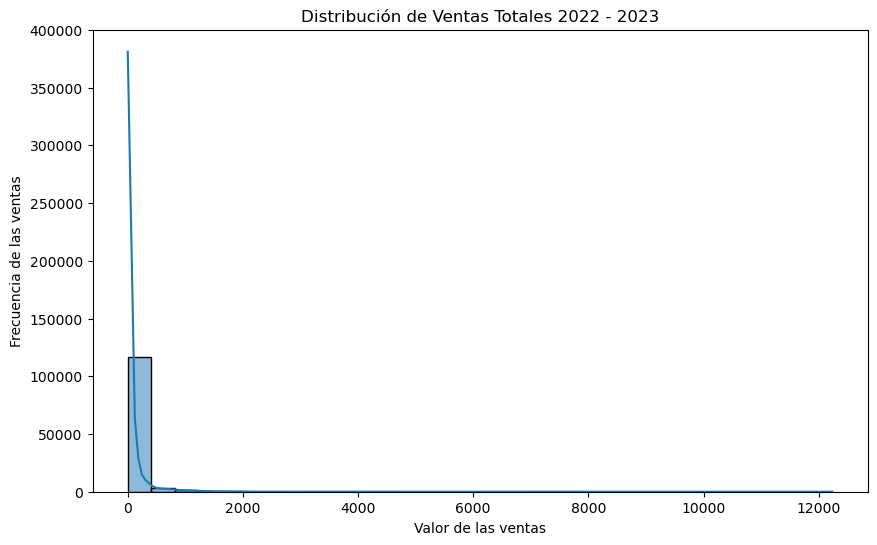

In [39]:
# Crea gráficos de distribución (histogramas o boxplots) para visualizar la distribución de ventas por diferentes categorías. 
# Esto ayudará a identificar patrones de ventas y posibles outliers.

# Creamos uan tabla que nos muestre la distribución de ventas totales en ambos años 
df = pd.read_csv('resultado.csv')

# Verificamos que esten bien importadas las liberias que utilizaremos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma general de la columna ventas
plt.figure(figsize=(10, 6))
sns.histplot(df['VALORES VENTAS TOTALES'], bins=30, kde=True)
plt.title('Distribución de Ventas Totales 2022 - 2023')
plt.xlabel('Valor de las ventas')
plt.ylabel('Frecuencia de las ventas')
plt.show()

### Como podemos observar, los valores claramente se inclinan en una mayor cantidad de ventas con valores menores a 100


Existen 50399 resultados


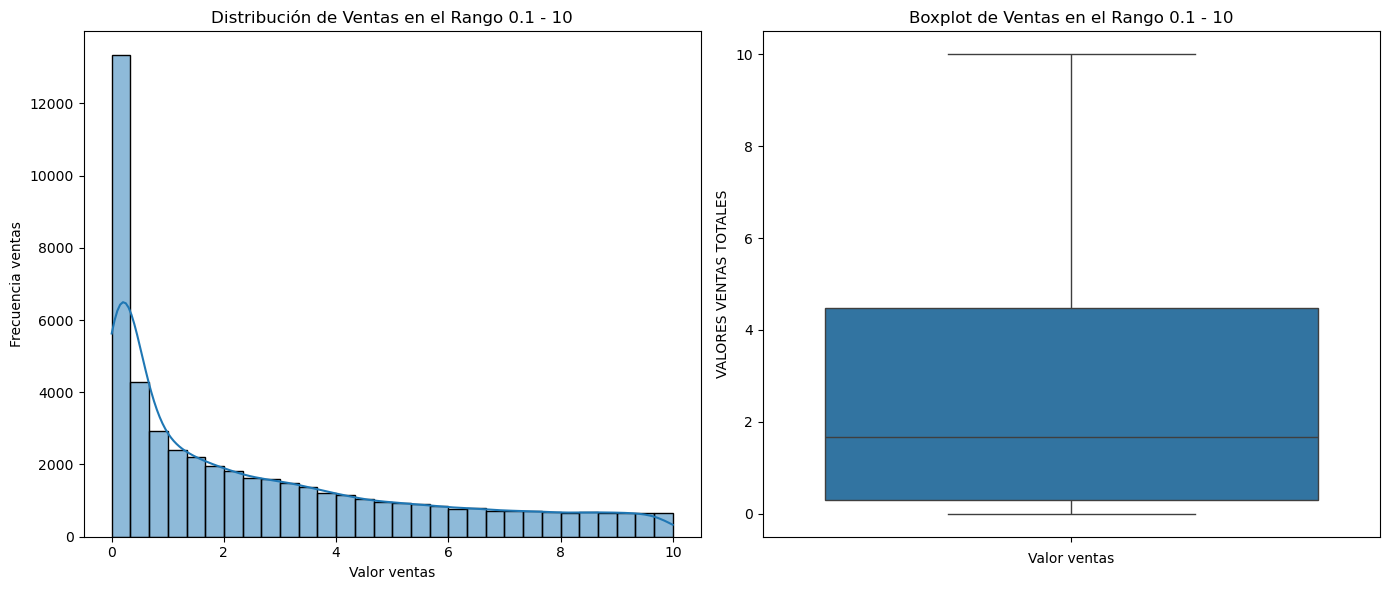


Existen 69900 resultados


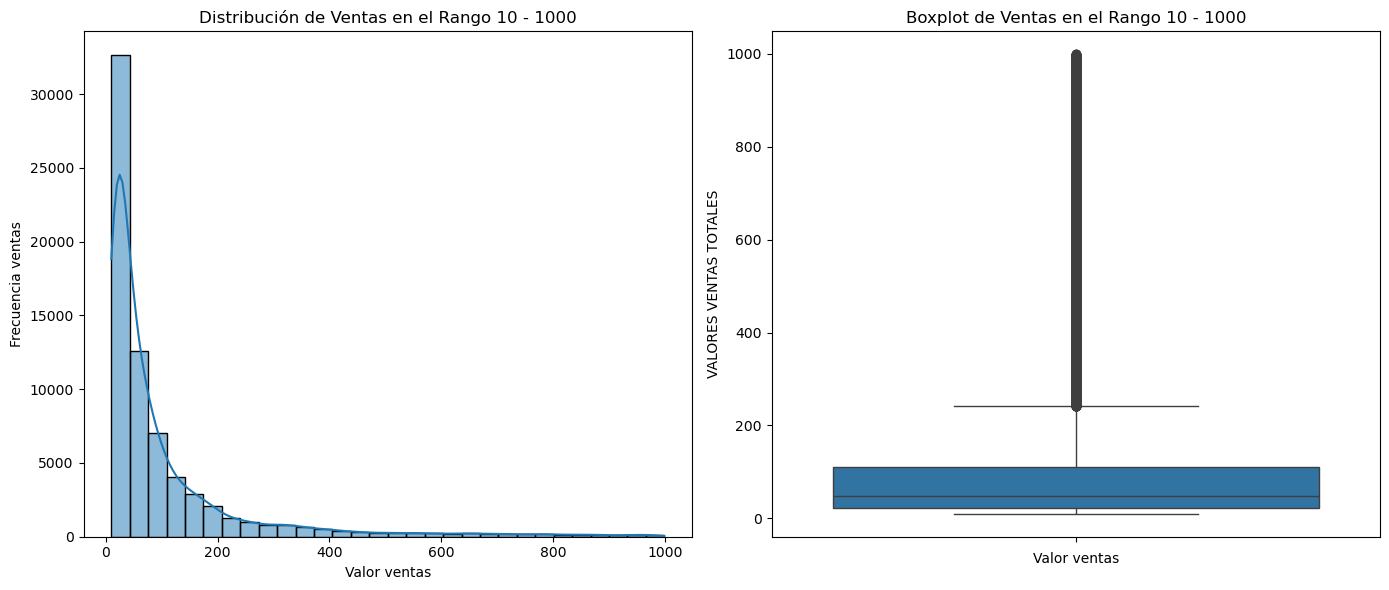


Existen 1703 resultados


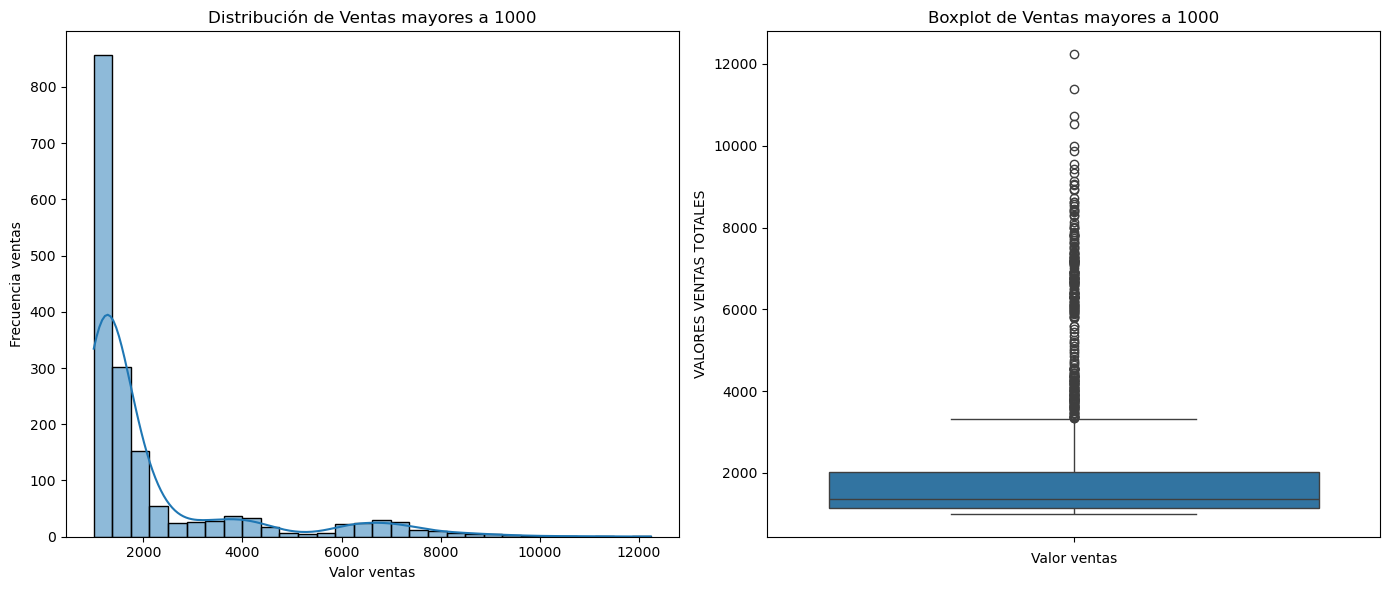

In [41]:
# La mejor opción para poder visualizar los datos sería partir las tablas en 3 
# La primera siendo las ventas menores a 10, la segunda todas las ventas mayores a 10 peor menores a 1000
# y por utlimo la tercera con todasa las ventas mayores a 1000

# Filtrar las filas que tengan ventas entre 0.1 y 10
df_rango = df[(df['VALORES VENTAS TOTALES'] <= 10 )]
print()
print(f"Existen {len(df_rango)} resultados")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribución de Ventas en el Rango 0.1 - 10')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title('Boxplot de Ventas en el Rango 0.1 - 10')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()



# Ventas en el rango 10 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 10) & (df['VALORES VENTAS TOTALES'] < 1000)]
print()
print(f"Existen {len(df_rango)} resultados")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribución de Ventas en el Rango 10 - 1000')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title('Boxplot de Ventas en el Rango 10 - 1000')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()



# Por ultimo creamos una visualización con la mayor cantidad de ventas restantes 
# Filtrar ventas mayores a 1000
df_rango = df[df['VALORES VENTAS TOTALES'] > 1000]
print()
print(f"Existen {len(df_rango)} resultados")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribución de Ventas mayores a 1000')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title('Boxplot de Ventas mayores a 1000')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()

### Se tomocomo refencia la columna de "Atributo_3" ya que era la mas completa y la que tenia mejor roganizados los diferentes productos

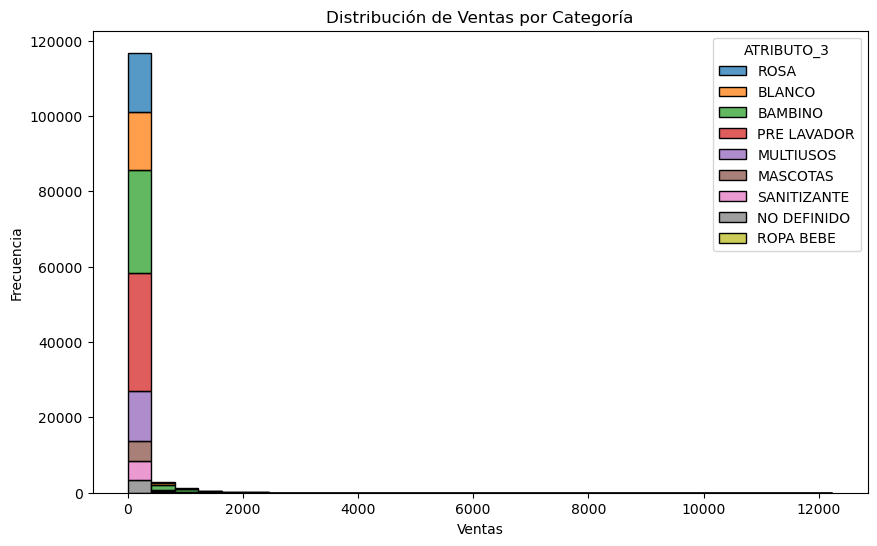

In [43]:
# Histograma de ventas por categoría general
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='VALORES VENTAS TOTALES', hue='ATRIBUTO_3', multiple='stack', bins=30)
plt.title('Distribución de Ventas por Categoría')
plt.xlabel('Ventas')
plt.ylabel('Frecuencia')
plt.show()

# Separaremos por atributo cada venta para una mejor visualización 
# ATRIBUTO "ROSA"


Existen 5841 resultados para el atributo 'ROSA' en el rango de ventas menores a 10


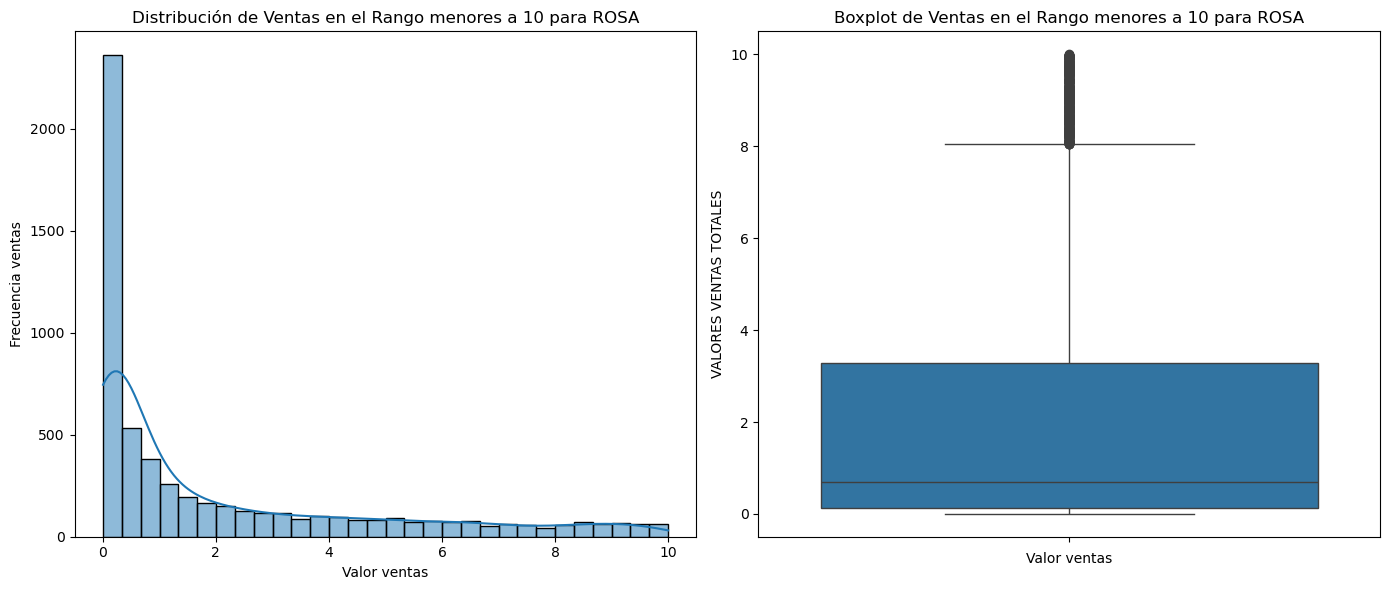


Existen 10475 resultados para el atributo 'ROSA' en el rango de ventas de 10 - 1000


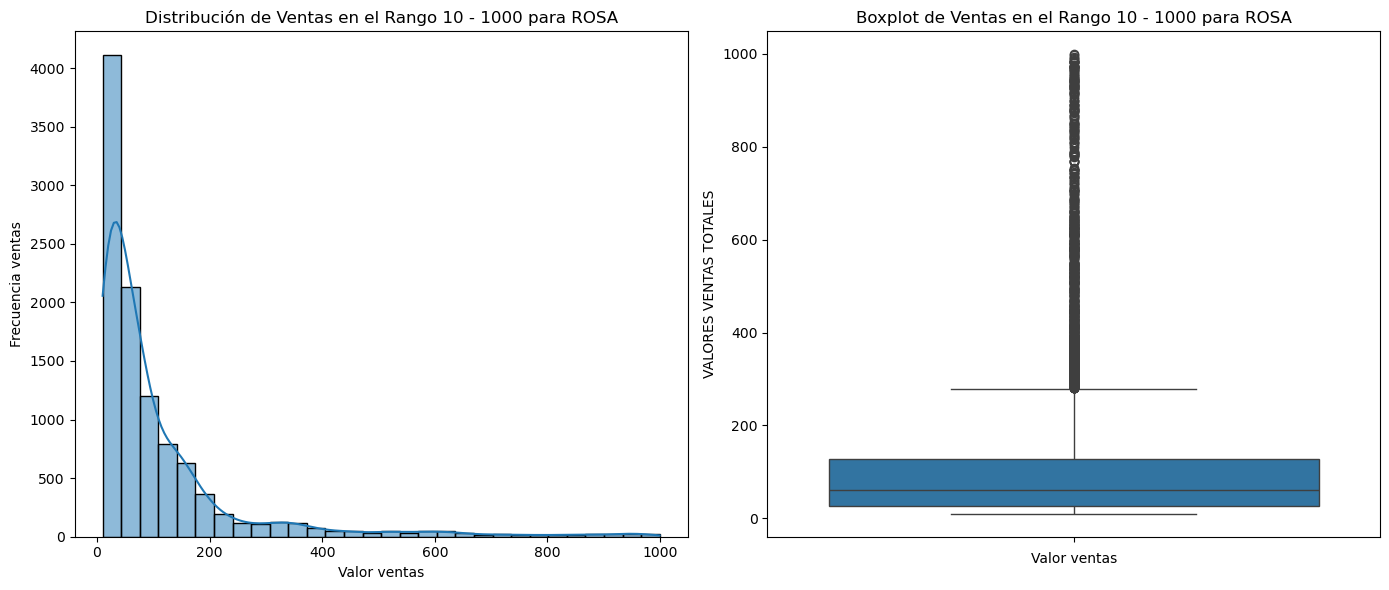


Existen 98 resultados para el atributo 'ROSA' en el rango de ventas mayores a 1000


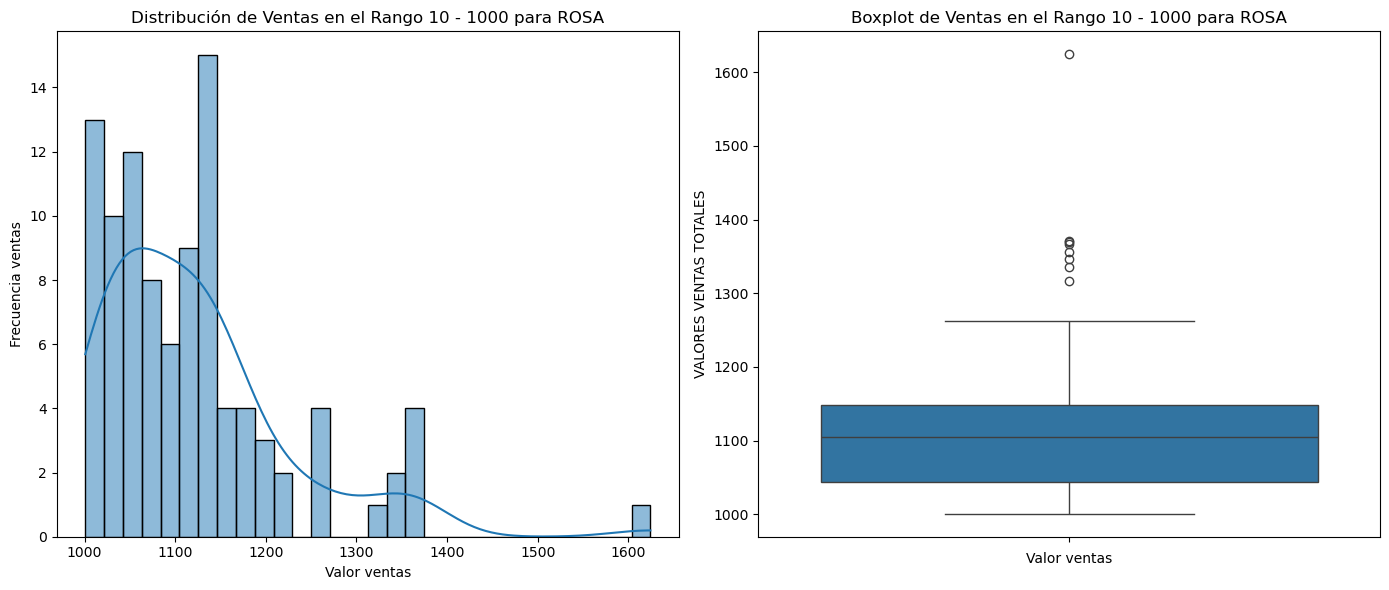

In [45]:
# Grafico que nos muestra la Distibución de ventas separadas en las 3 tablas antes establecidas de acuerdo a cada atributo

# Atributo "ROSA"
atributo = 'ROSA'

# Filtrar ventas en el rango 0 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] <= 10) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas menores a 10")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango menores a 10 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango menores a 10 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()



# Filtrar ventas en el rango 10 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 10) & (df['VALORES VENTAS TOTALES'] <= 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas de 10 - 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()




# Por ultimo creamos una visualización con la mayor cantidad de ventas restantes 
# Filtrar ventas mayores a 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas mayores a 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()

# ATRIBUTO "BLANCO"


Existen 5361 resultados para el atributo 'BLANCO' en el rango de ventas menores a 10


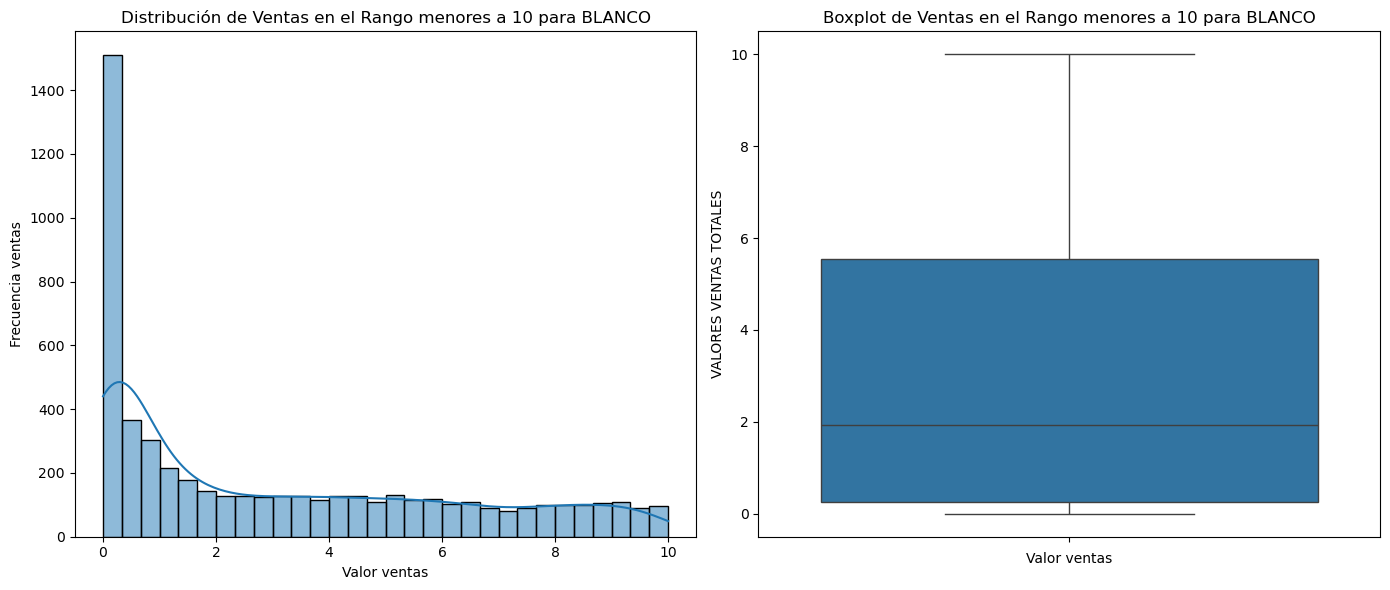


Existen 10451 resultados para el atributo 'BLANCO' en el rango de ventas de 10 - 1000


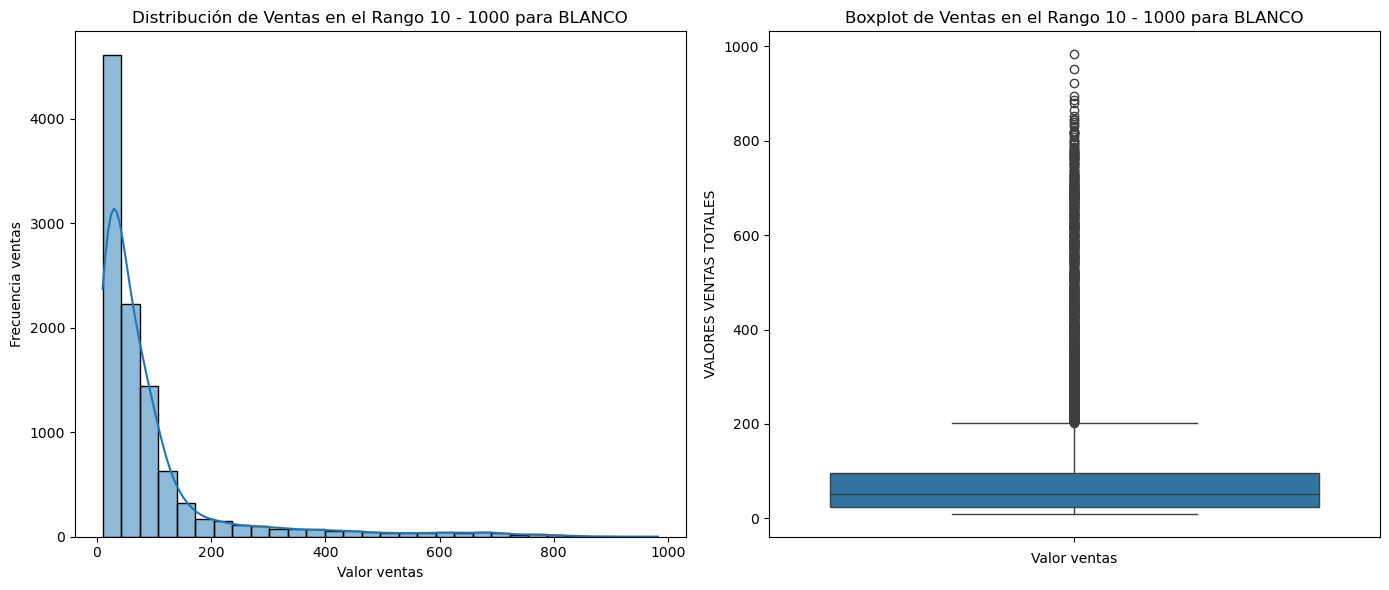


Existen 0 resultados para el atributo 'BLANCO' en el rango de ventas mayores a 1000


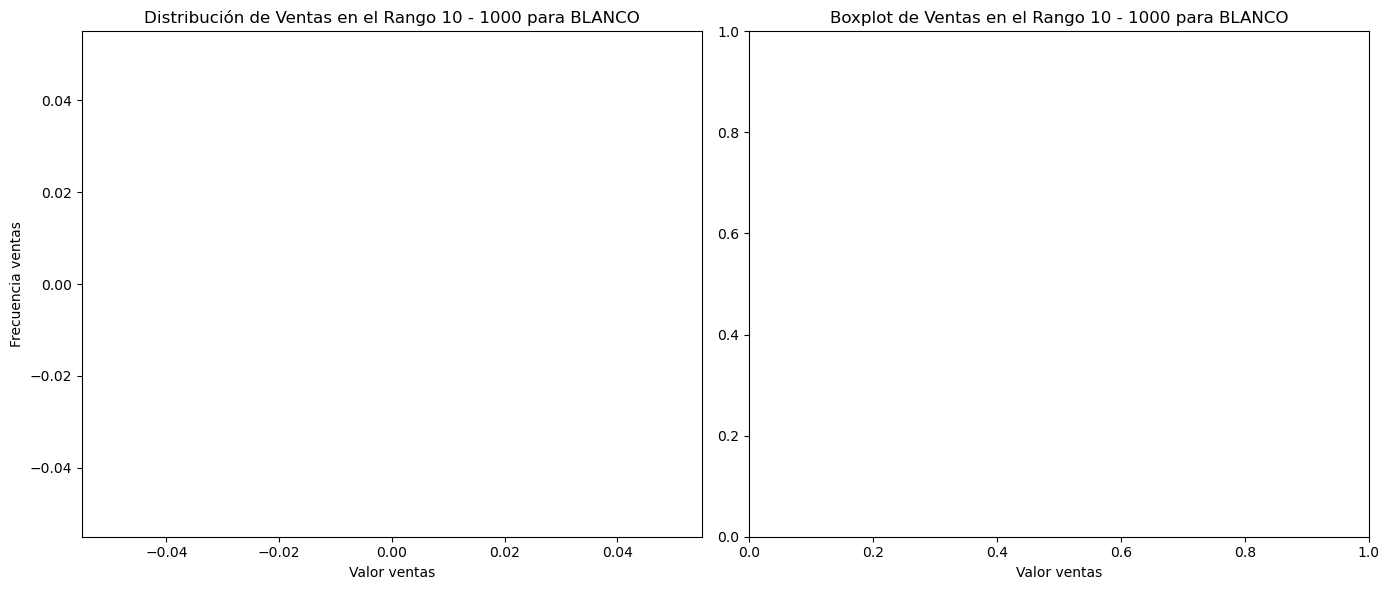

In [48]:
# Atributo "BLANCO"
atributo = 'BLANCO'

# Filtrar ventas en el rango 0 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] <= 10) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas menores a 10")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango menores a 10 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango menores a 10 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()



# Filtrar ventas en el rango 10 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 10) & (df['VALORES VENTAS TOTALES'] <= 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas de 10 - 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()




# Por ultimo creamos una visualización con la mayor cantidad de ventas restantes 
# Filtrar ventas mayores a 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas mayores a 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()

# ATRIBUTO "BAMBINO"


Existen 12646 resultados para el atributo 'BAMBINO' en el rango de ventas menores a 10


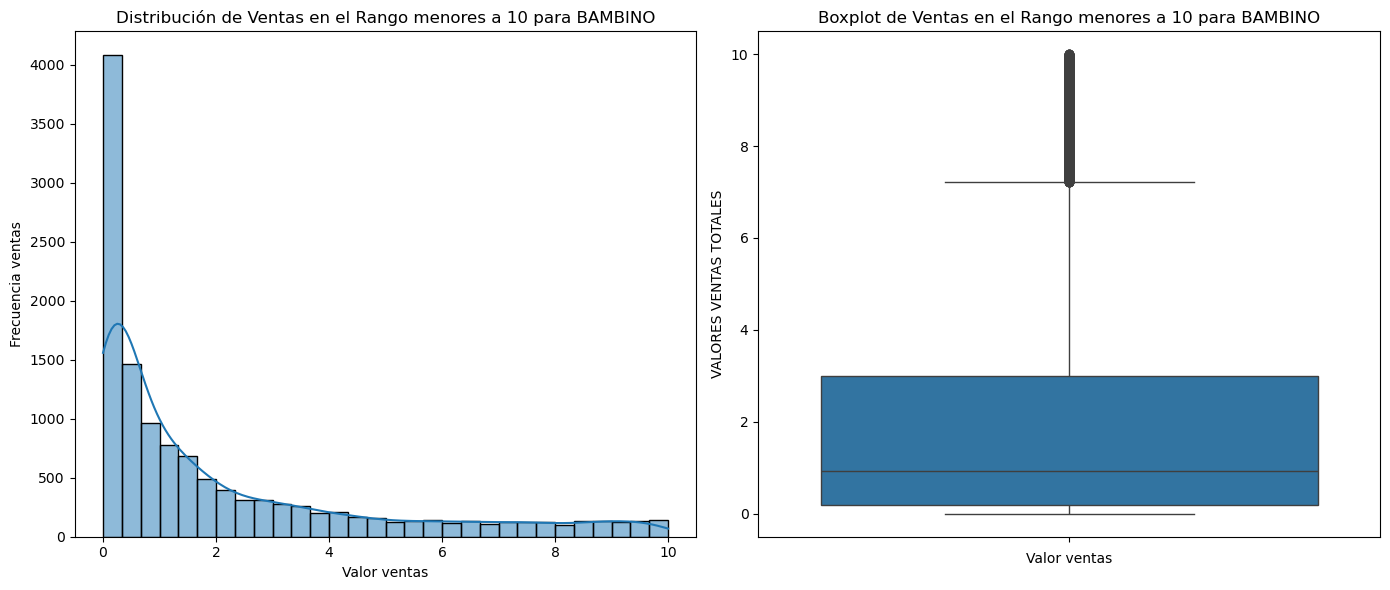


Existen 16466 resultados para el atributo 'BAMBINO' en el rango de ventas de 10 - 1000


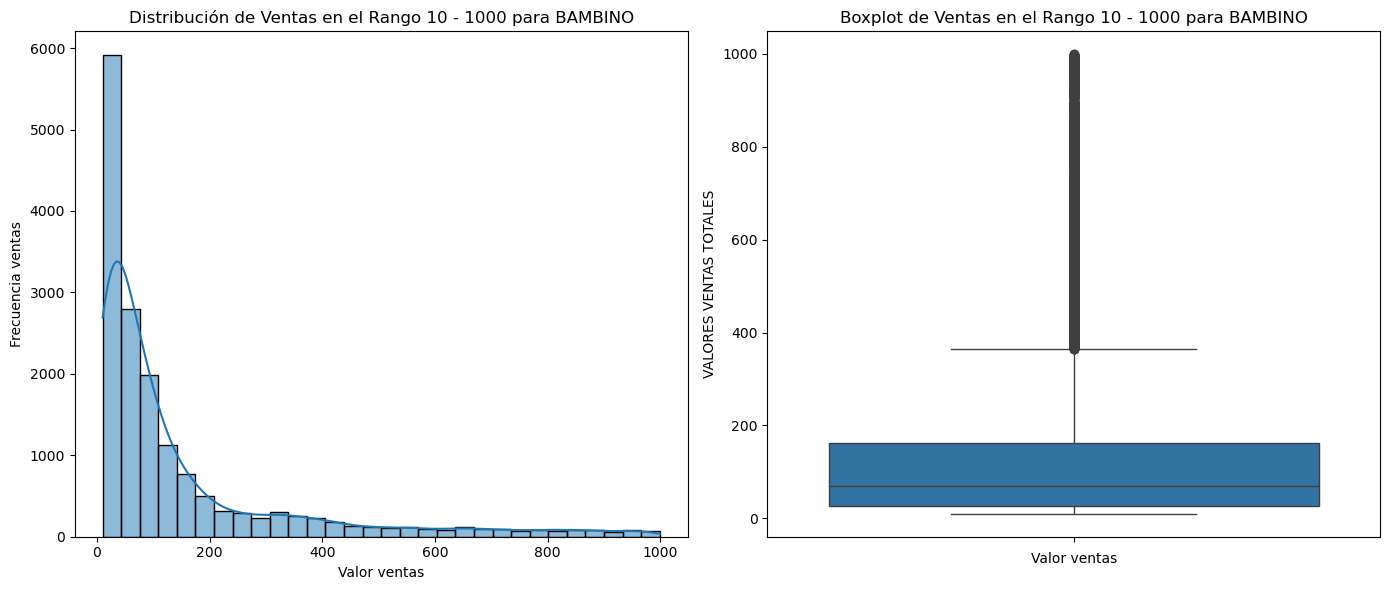


Existen 1288 resultados para el atributo 'BAMBINO' en el rango de ventas mayores a 1000


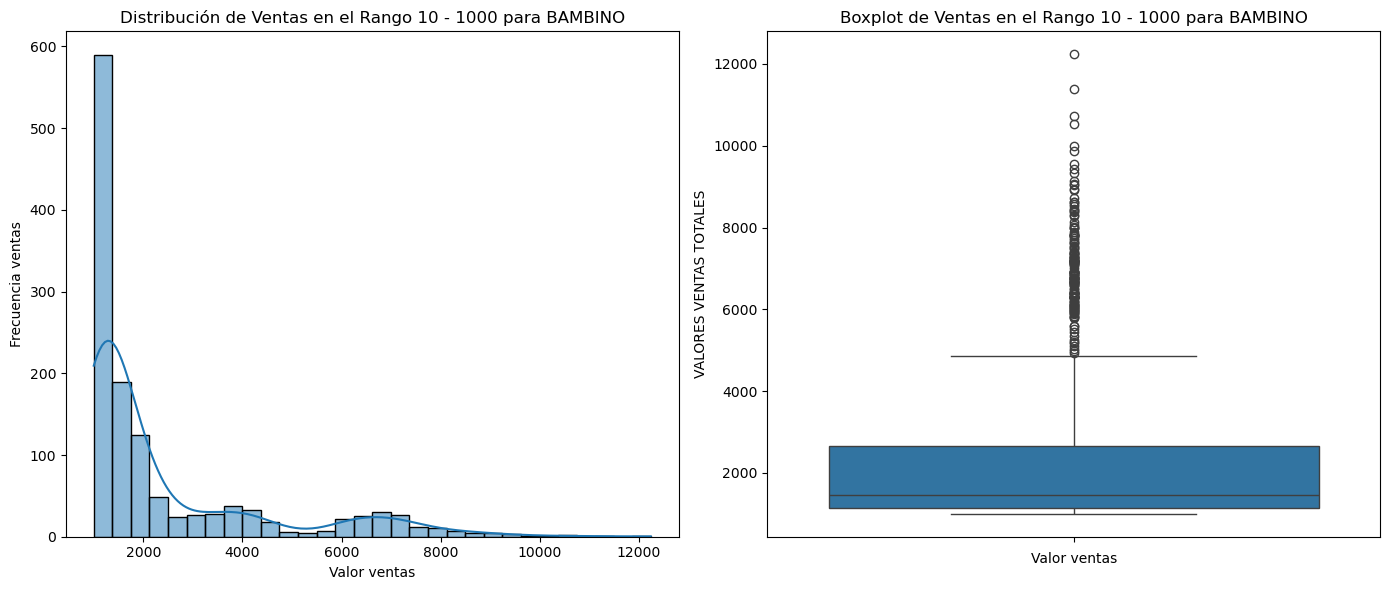

In [52]:
# Atributo "BAMBINO"
atributo = 'BAMBINO'

# Filtrar ventas en el rango 0 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] <= 10) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas menores a 10")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango menores a 10 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango menores a 10 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()


# Filtrar ventas en el rango 10 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 10) & (df['VALORES VENTAS TOTALES'] <= 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas de 10 - 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()


# Por ultimo creamos una visualización con la mayor cantidad de ventas restantes 
# Filtrar ventas mayores a 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas mayores a 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()

# ATRIBUTO "PRE LAVADOR"


Existen 13842 resultados para el atributo 'PRE LAVADOR' en el rango de ventas menores a 10


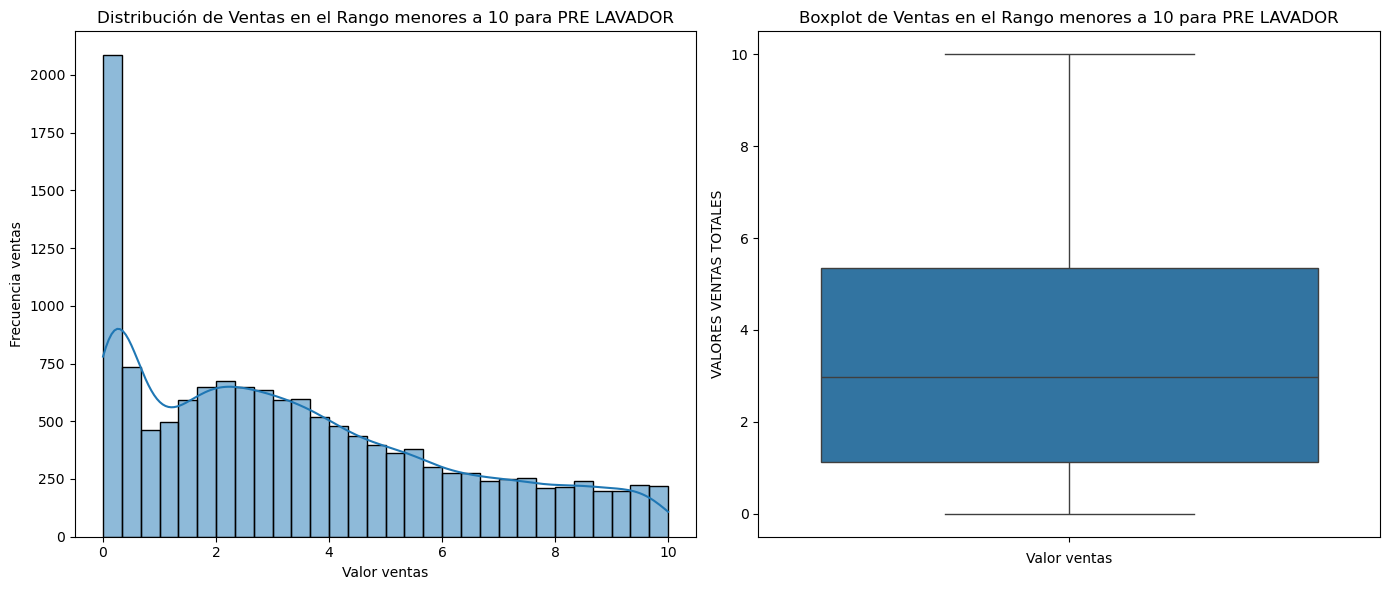


Existen 17664 resultados para el atributo 'PRE LAVADOR' en el rango de ventas de 10 - 1000


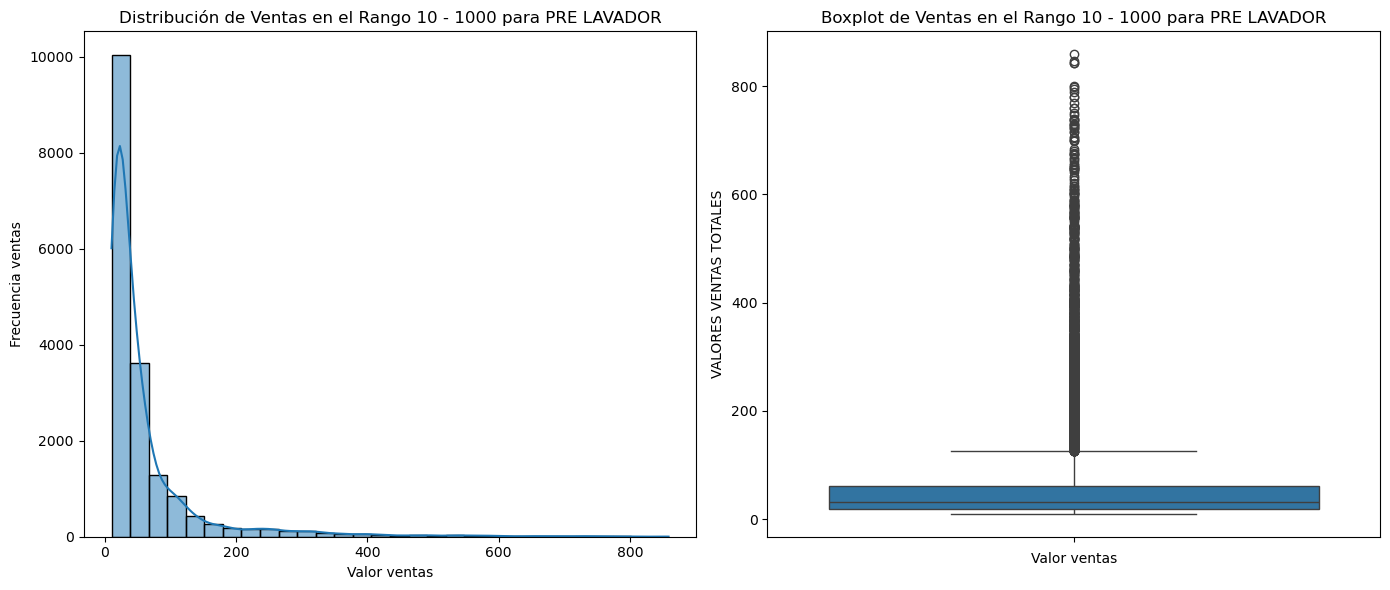


Existen 1 resultados para el atributo 'PRE LAVADOR' en el rango de ventas mayores a 1000


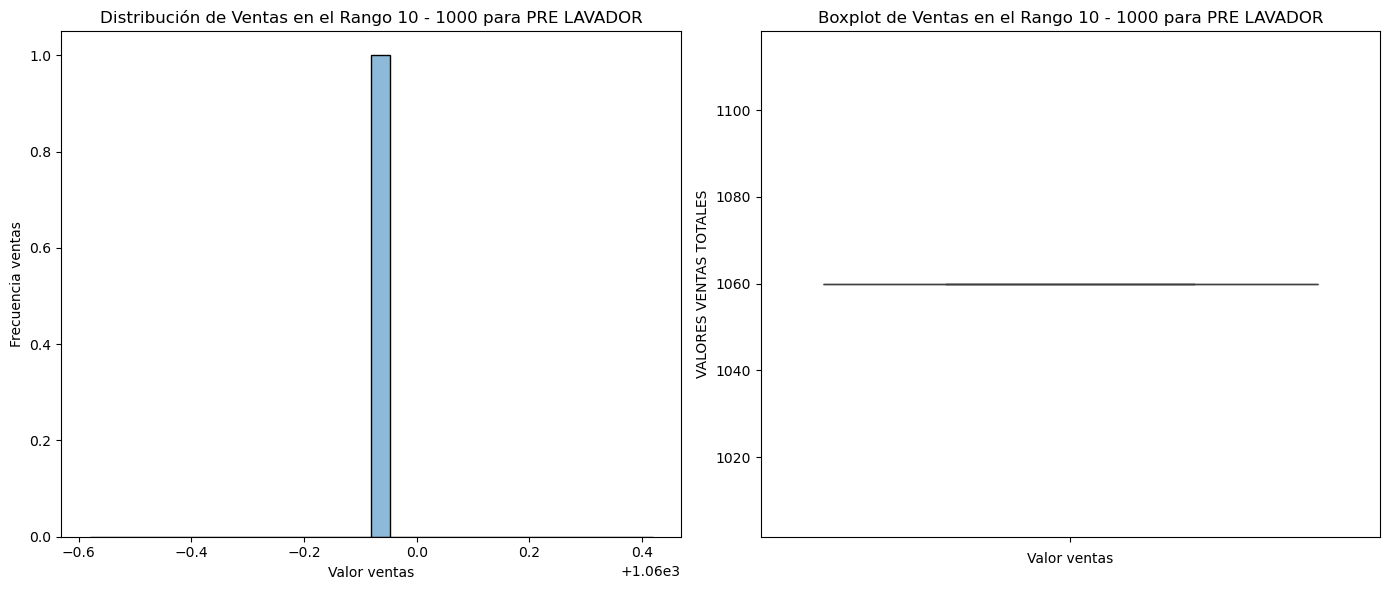

In [55]:
atributo = 'PRE LAVADOR'

# Filtrar ventas en el rango 0 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] <= 10) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas menores a 10")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango menores a 10 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango menores a 10 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()



# Filtrar ventas en el rango 10 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 10) & (df['VALORES VENTAS TOTALES'] <= 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas de 10 - 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()




# Por ultimo creamos una visualización con la mayor cantidad de ventas restantes 
# Filtrar ventas mayores a 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas mayores a 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()

# ATRIBUTO "MULTIUSOS"


Existen 5014 resultados para el atributo 'MULTIUSOS' en el rango de ventas menores a 10


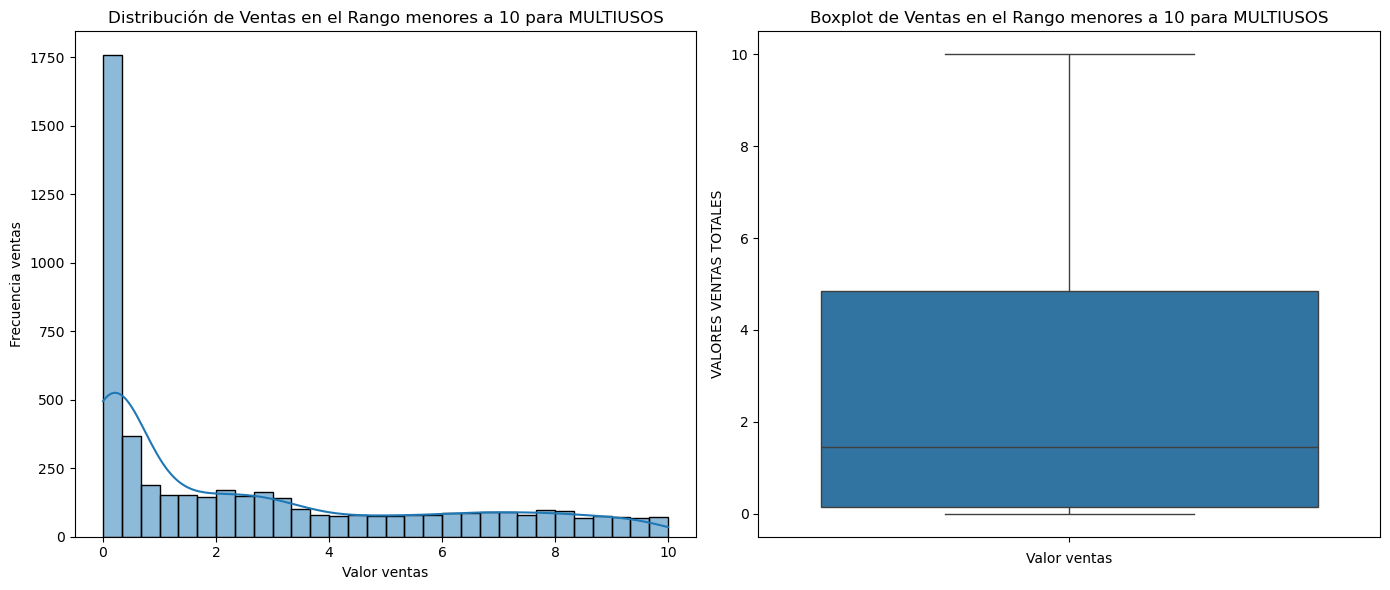


Existen 8575 resultados para el atributo 'MULTIUSOS' en el rango de ventas de 10 - 1000


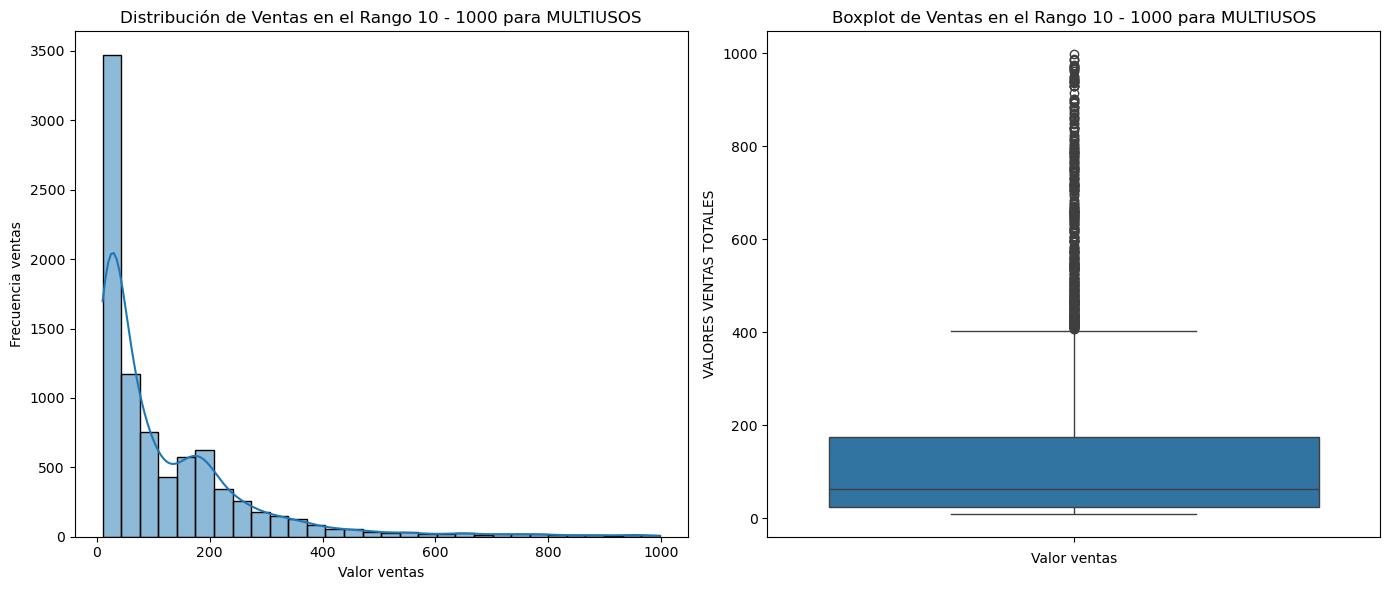


Existen 310 resultados para el atributo 'MULTIUSOS' en el rango de ventas mayores a 1000


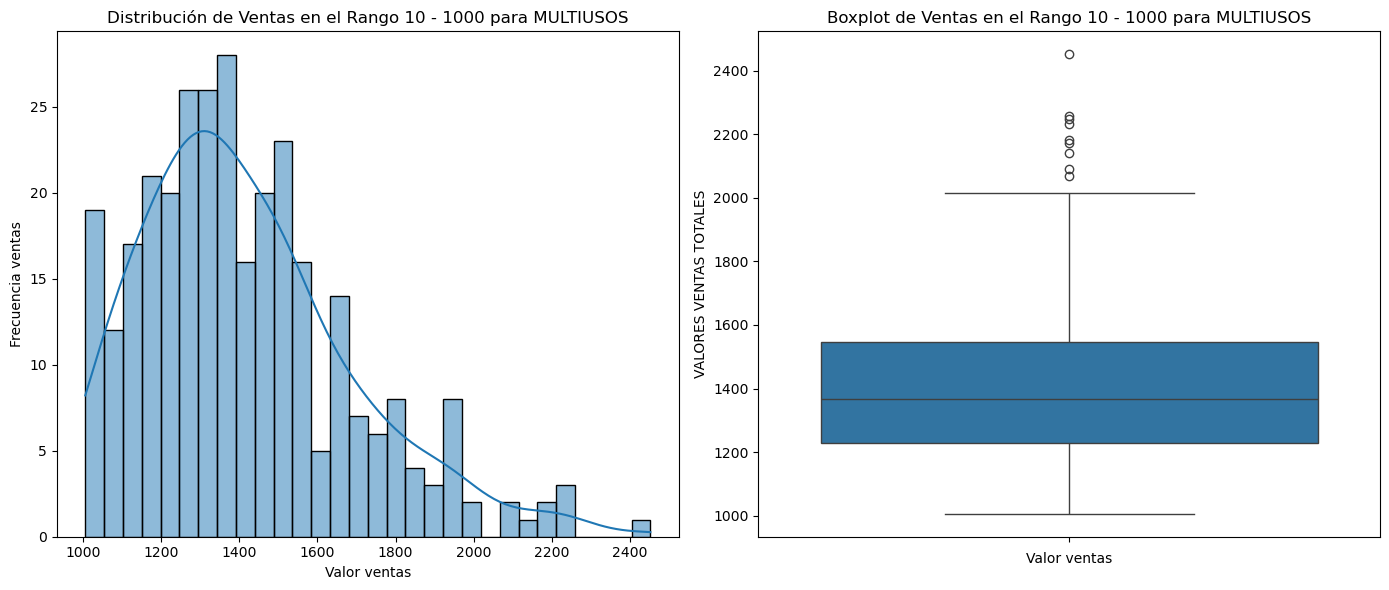

In [58]:
# Atributo "MULTIUSOS"
atributo = 'MULTIUSOS'

# Filtrar ventas en el rango 0 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] <= 10) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas menores a 10")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango menores a 10 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango menores a 10 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()


# Filtrar ventas en el rango 10 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 10) & (df['VALORES VENTAS TOTALES'] <= 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas de 10 - 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()


# Por ultimo creamos una visualización con la mayor cantidad de ventas restantes 
# Filtrar ventas mayores a 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas mayores a 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()

# ATRIBUTO "MASCOTAS"


Existen 2281 resultados para el atributo 'MASCOTAS' en el rango de ventas menores a 10


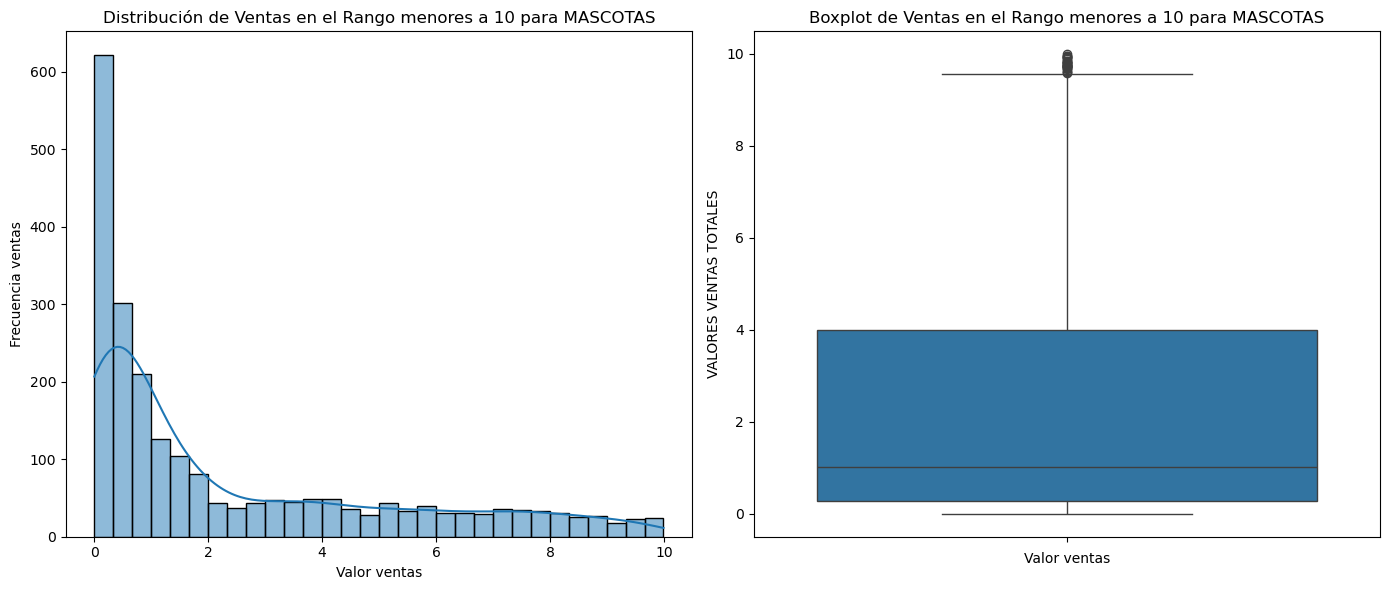


Existen 3284 resultados para el atributo 'MASCOTAS' en el rango de ventas de 10 - 1000


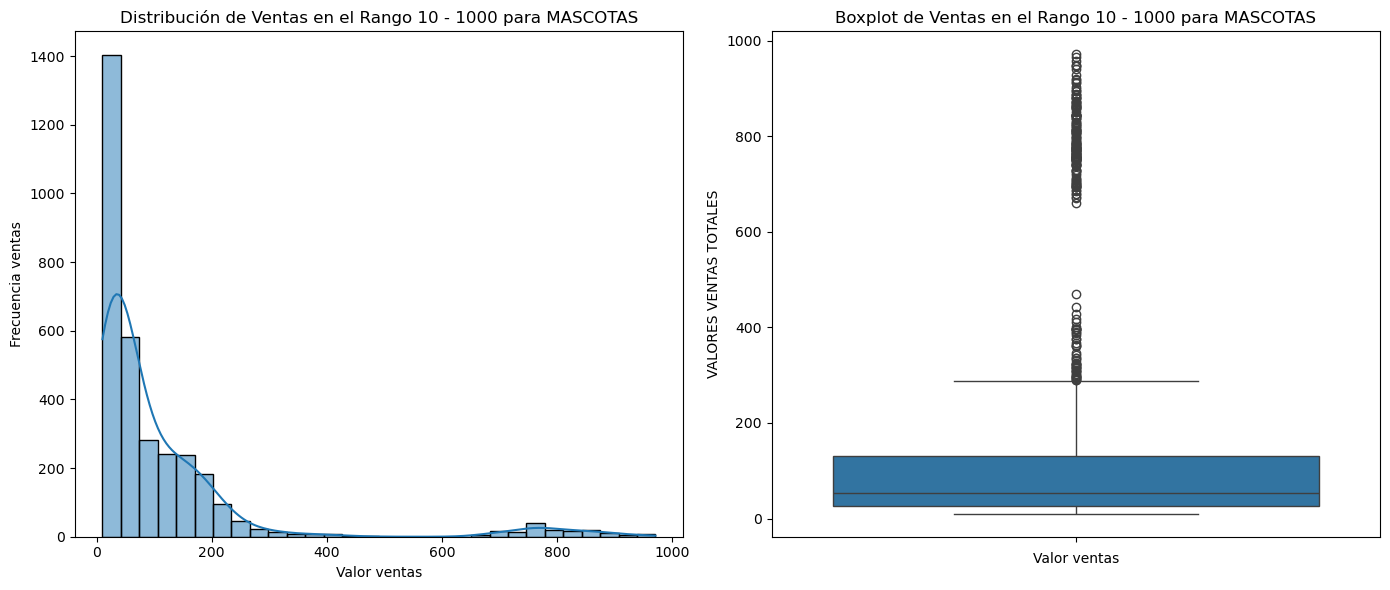


Existen 6 resultados para el atributo 'MASCOTAS' en el rango de ventas mayores a 1000


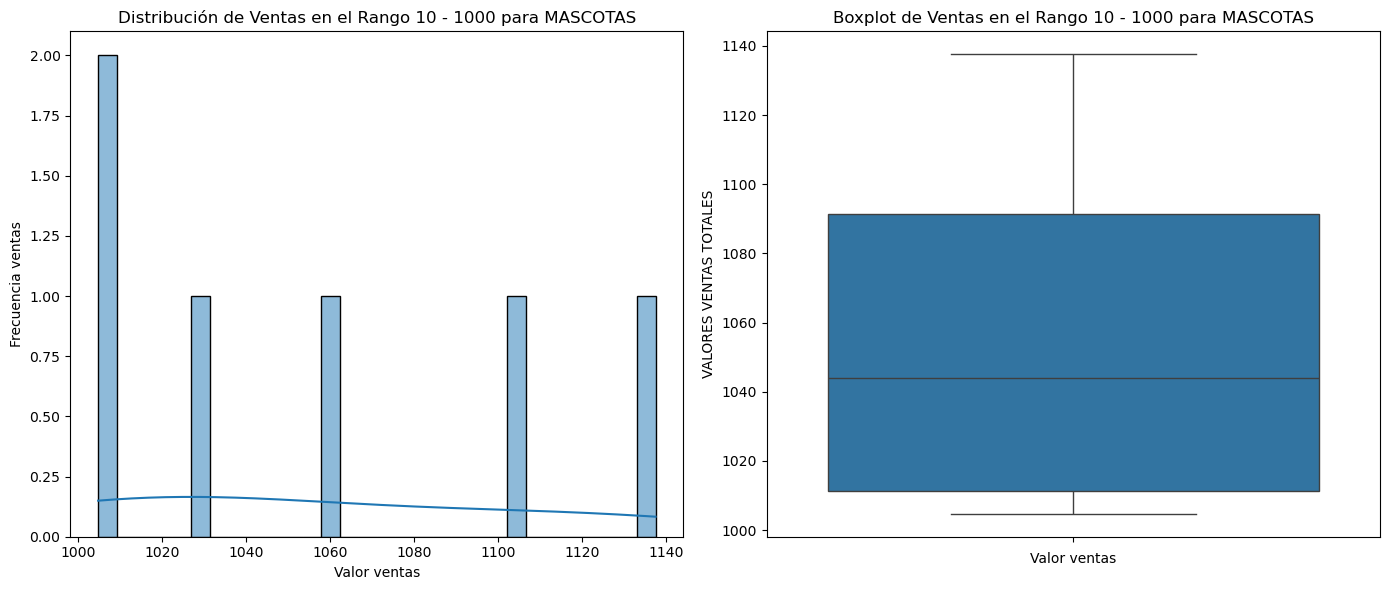

In [61]:
# Atributo "MASCOTAS"
atributo = 'MASCOTAS'

# Filtrar ventas en el rango 0 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] <= 10) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas menores a 10")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango menores a 10 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango menores a 10 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()


# Filtrar ventas en el rango 10 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 10) & (df['VALORES VENTAS TOTALES'] <= 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas de 10 - 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()


# Por ultimo creamos una visualización con la mayor cantidad de ventas restantes 
# Filtrar ventas mayores a 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas mayores a 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()

# ATRIBUTO "SANITIZANTE"


Existen 3288 resultados para el atributo 'SANITIZANTE' en el rango de ventas menores a 10


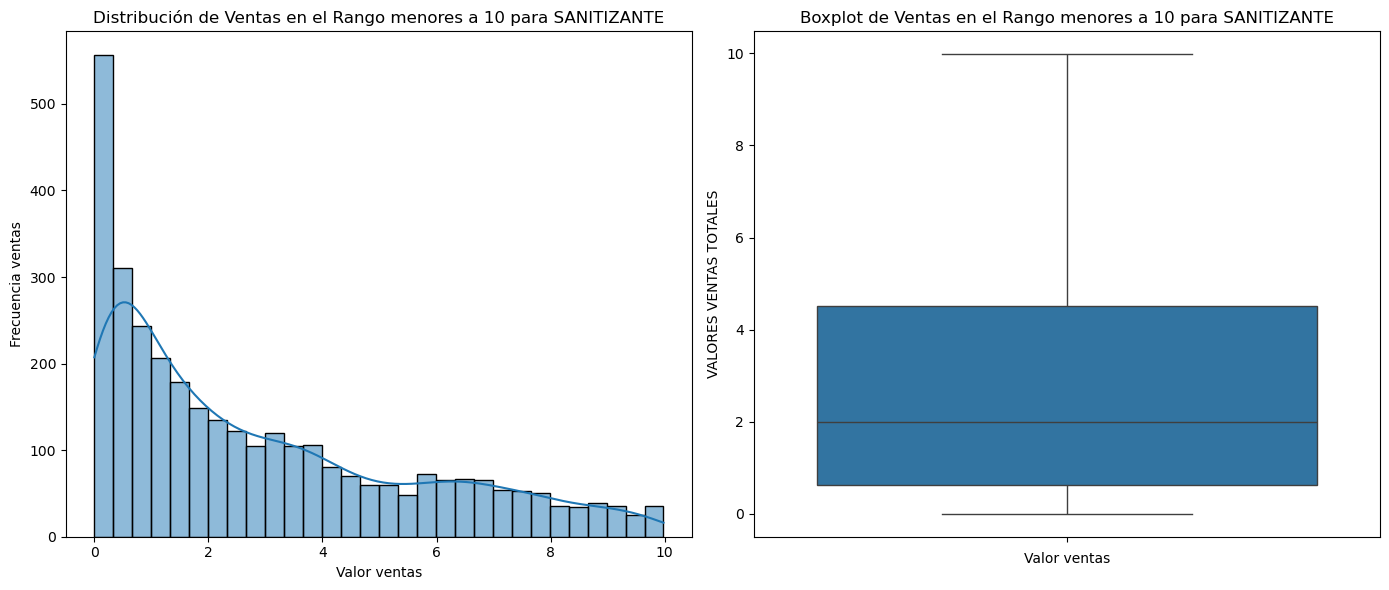


Existen 1735 resultados para el atributo 'SANITIZANTE' en el rango de ventas de 10 - 1000


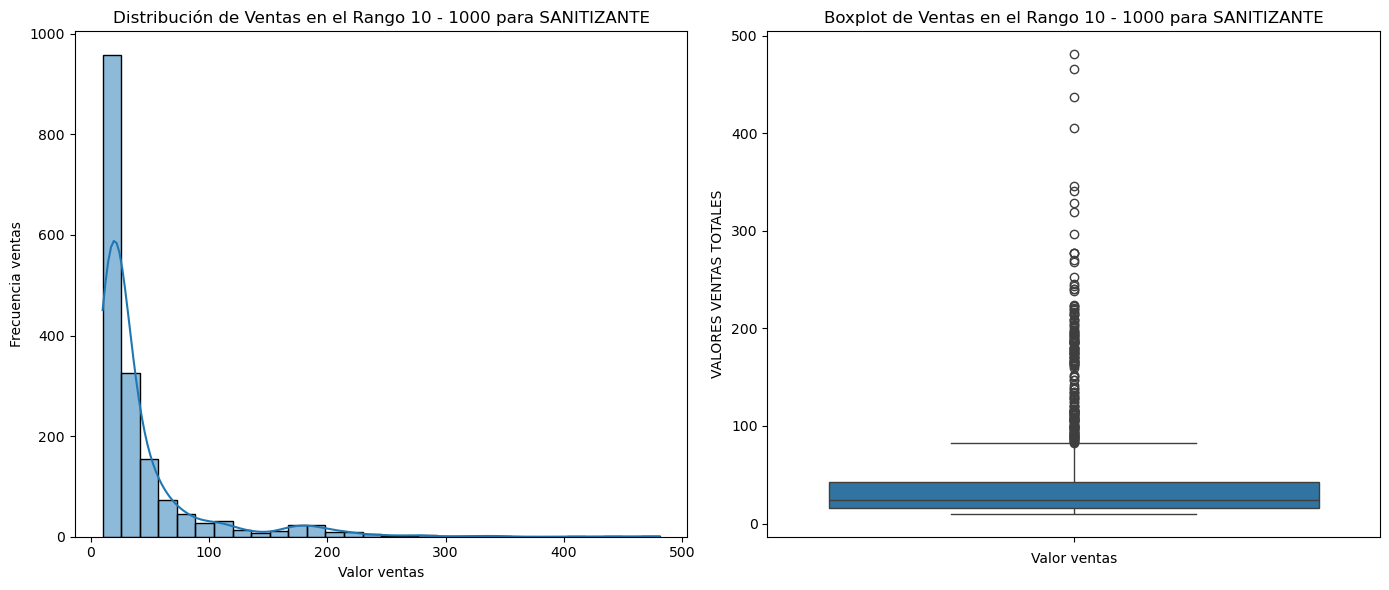


Existen 0 resultados para el atributo 'SANITIZANTE' en el rango de ventas mayores a 1000


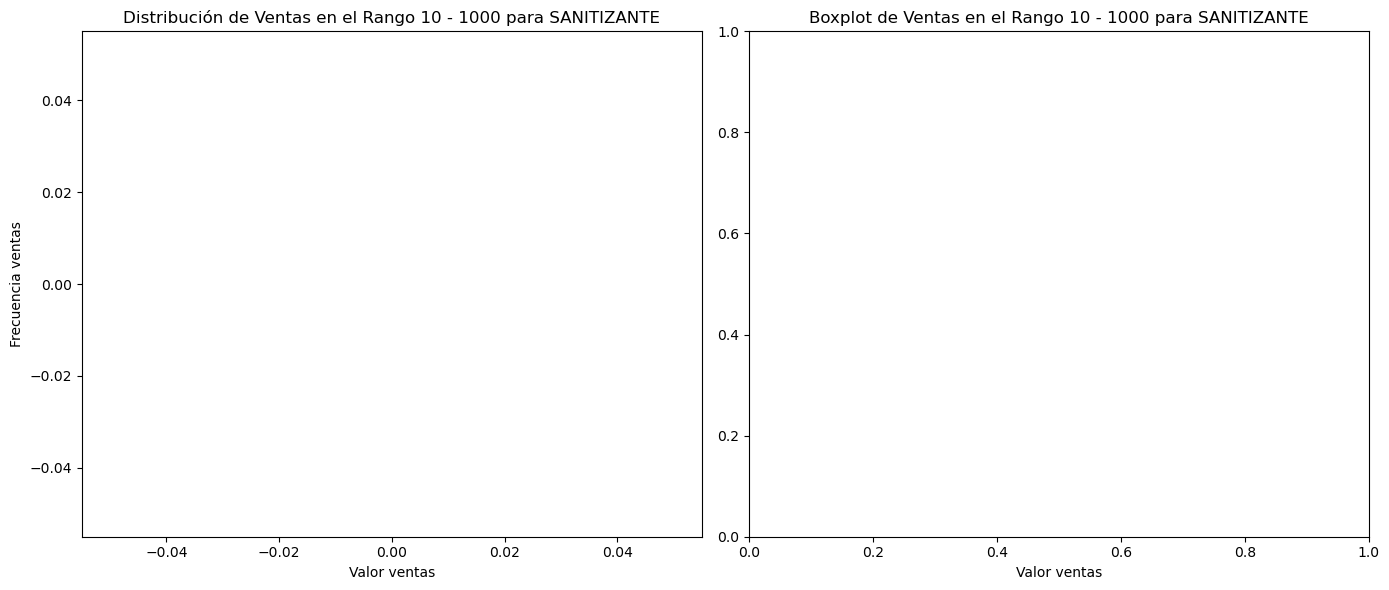

In [64]:
# Atributo "SANITIZANTE"
atributo = 'SANITIZANTE'

# Filtrar ventas en el rango 0 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] <= 10) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas menores a 10")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango menores a 10 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango menores a 10 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()


# Filtrar ventas en el rango 10 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 10) & (df['VALORES VENTAS TOTALES'] <= 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas de 10 - 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()


# Por ultimo creamos una visualización con la mayor cantidad de ventas restantes 
# Filtrar ventas mayores a 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas mayores a 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()

# ATRIBUTO "NO DEFINIDO"


Existen 2122 resultados para el atributo 'NO DEFINIDO' en el rango de ventas menores a 10


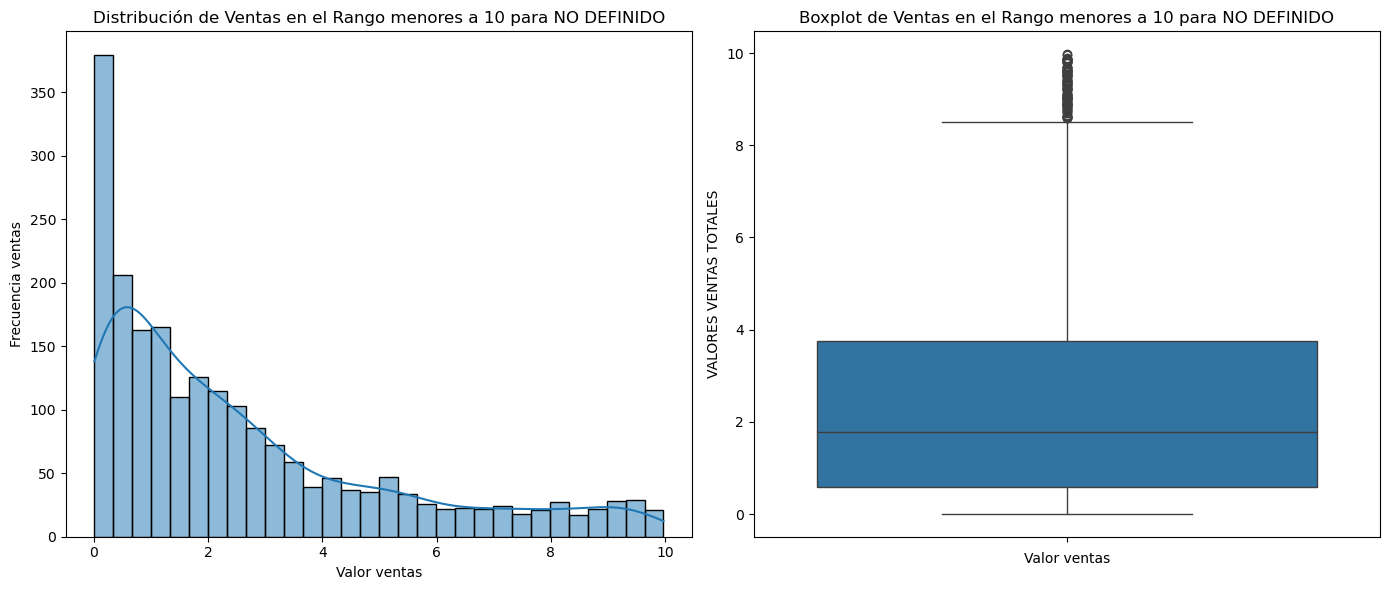


Existen 1250 resultados para el atributo 'NO DEFINIDO' en el rango de ventas de 10 - 1000


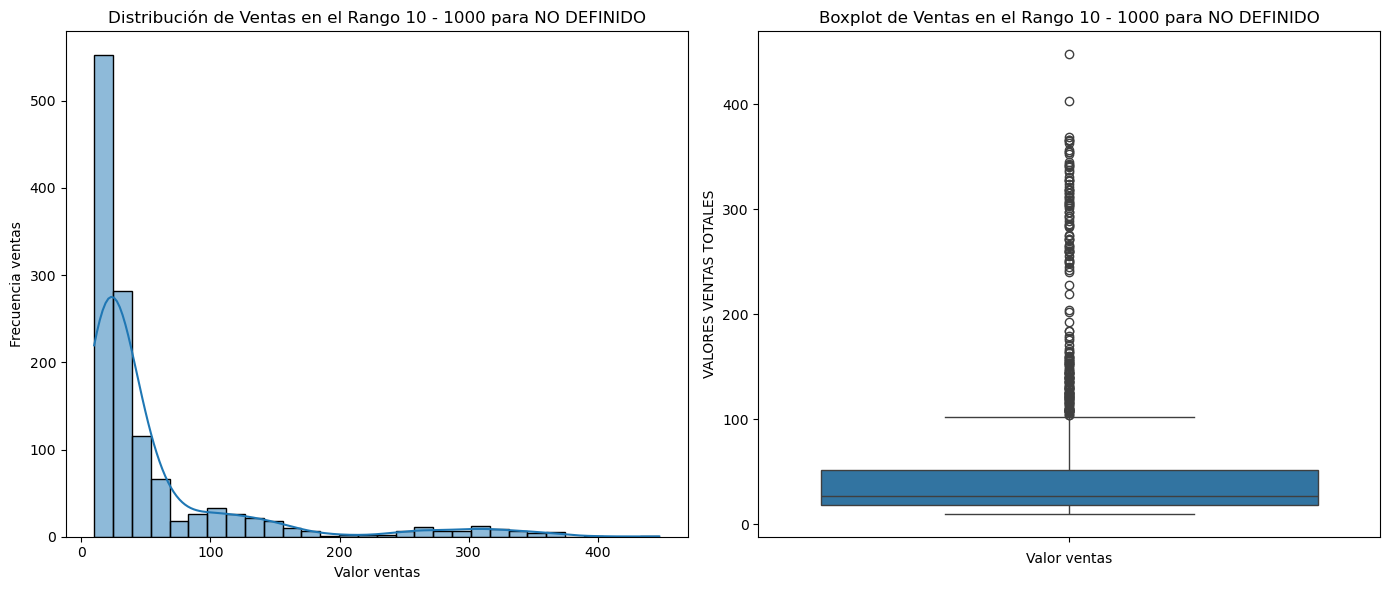


Existen 0 resultados para el atributo 'NO DEFINIDO' en el rango de ventas mayores a 1000


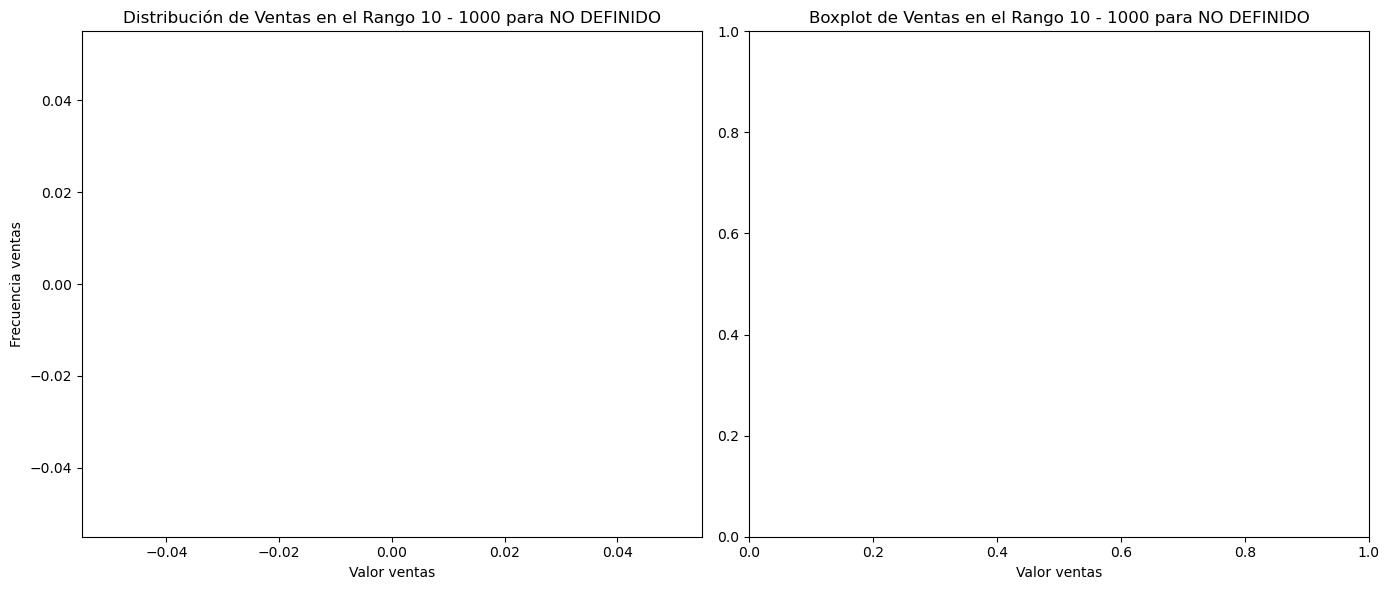

In [67]:
# Atributo "NO DEFINIDO"
atributo = 'NO DEFINIDO'

# Filtrar ventas en el rango 0 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] <= 10) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas menores a 10")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango menores a 10 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango menores a 10 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()


# Filtrar ventas en el rango 10 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 10) & (df['VALORES VENTAS TOTALES'] <= 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas de 10 - 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()


# Por ultimo creamos una visualización con la mayor cantidad de ventas restantes 
# Filtrar ventas mayores a 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas mayores a 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()

# ATRIBUTO "ROPA BEBE"


Existen 4 resultados para el atributo 'ROPA BEBE' en el rango de ventas menores a 10


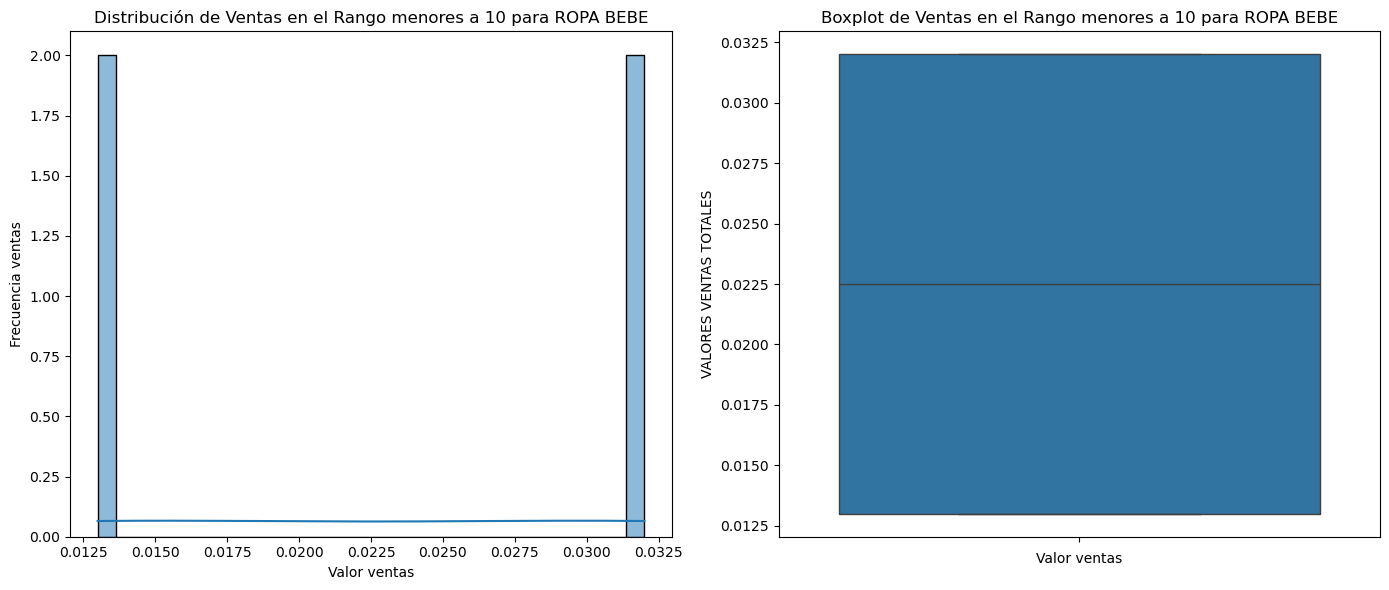


Existen 0 resultados para el atributo 'ROPA BEBE' en el rango de ventas de 10 - 1000


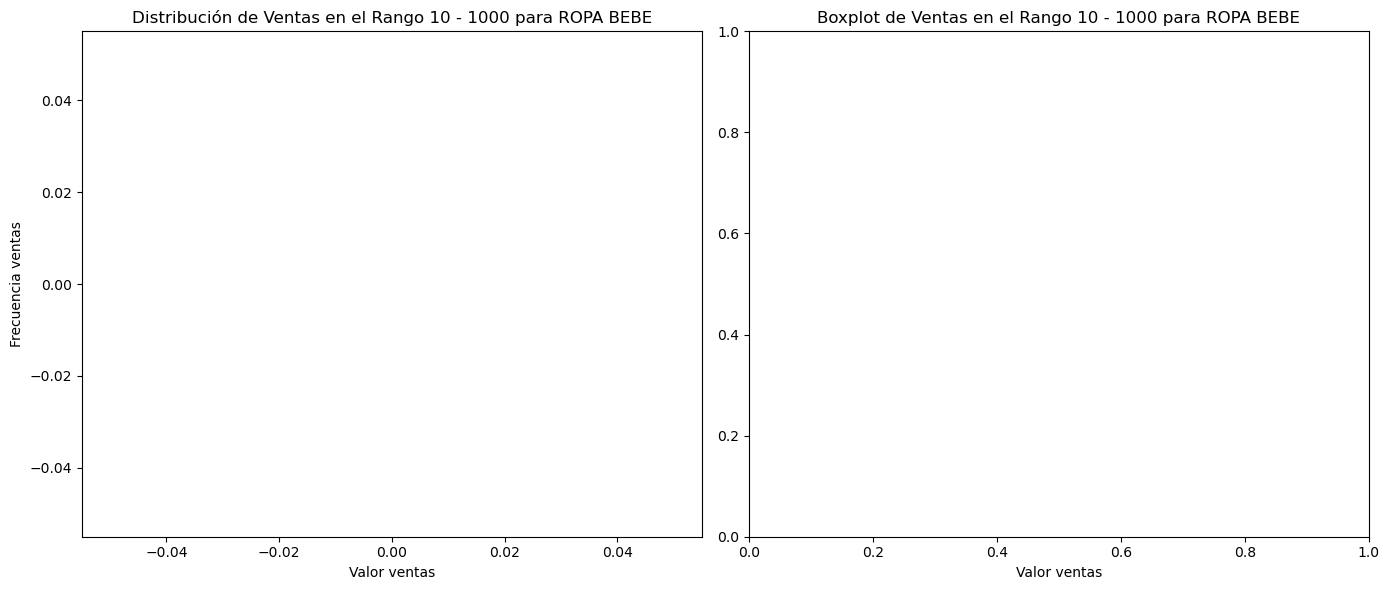


Existen 0 resultados para el atributo 'ROPA BEBE' en el rango de ventas mayores a 1000


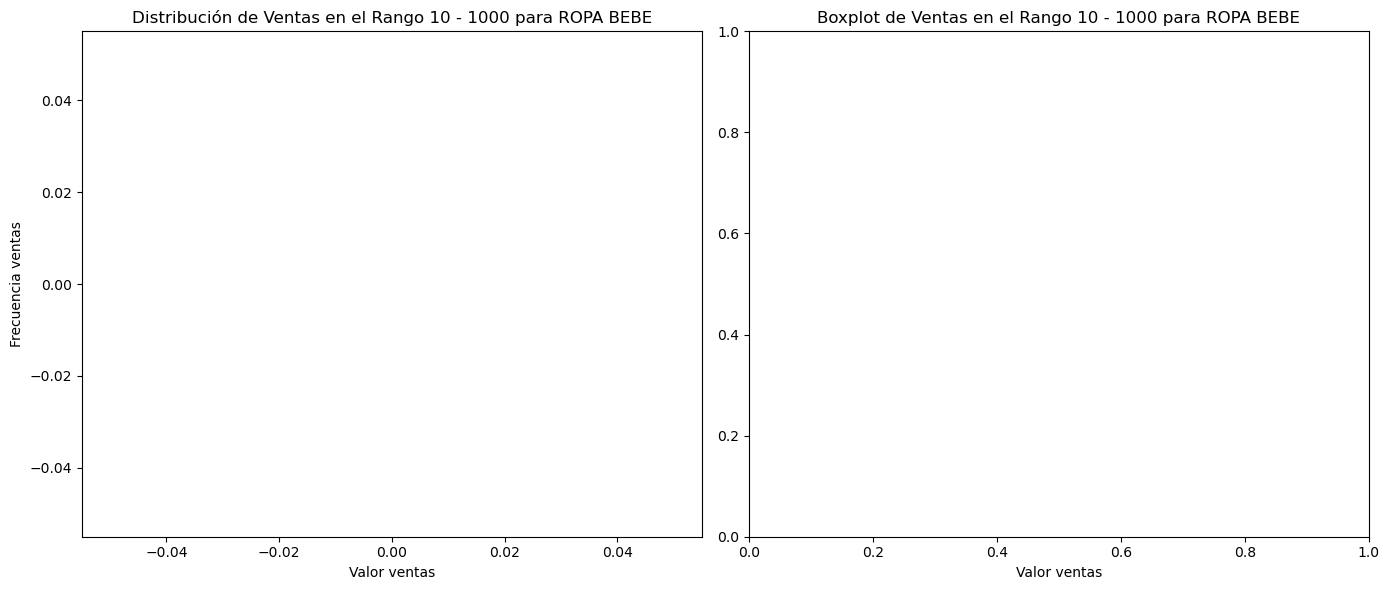

In [72]:
# Atributo "ROPA BEBE"
atributo = 'ROPA BEBE'

# Filtrar ventas en el rango 0 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] <= 10) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas menores a 10")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango menores a 10 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango menores a 10 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()


# Filtrar ventas en el rango 10 - 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 10) & (df['VALORES VENTAS TOTALES'] <= 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas de 10 - 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()


# Por ultimo creamos una visualización con la mayor cantidad de ventas restantes 
# Filtrar ventas mayores a 1000
df_rango = df[(df['VALORES VENTAS TOTALES'] > 1000) & (df['ATRIBUTO_3'] == atributo)]
print()
print(f"Existen {len(df_rango)} resultados para el atributo '{atributo}' en el rango de ventas mayores a 1000")

# Crear subplots: 1 fila, 2 columnas (histograma y boxplot juntos)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma en el subplot de la izquierda
sns.histplot(df_rango['VALORES VENTAS TOTALES'], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f'Distribución de Ventas en el Rango 10 - 1000 para {atributo}')
axes[0].set_xlabel('Valor ventas')
axes[0].set_ylabel('Frecuencia ventas')

# Boxplot en el subplot de la derecha
sns.boxplot(df_rango['VALORES VENTAS TOTALES'], ax=axes[1])
axes[1].set_title(f'Boxplot de Ventas en el Rango 10 - 1000 para {atributo}')
axes[1].set_xlabel('Valor ventas')

plt.tight_layout()
plt.show()

# Nota
### Como podemos observar, la categoria de pre-lavador es la que mas peso tiene dentro de las ventas, ya que al analizar de igual forma mas a fondo cada categoria, pdemos ver que la centración de ventas es mas alta en valores mayores que las demás.

# Analizar la tendencia de ventas en el tiempo

In [76]:
# Genera gráficos de líneas que muestren las tendencias de ventas a lo largo del tiempo. Filtra las ventas por diferentes productos, 
# regiones o segmentos para analizar cómo han cambiado las ventas a lo largo del tiempo.

C:\Users\AlanHDLR\AppData\Local\Temp\ipykernel_39976\4066671234.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MES', y='VALORES VENTAS TOTALES', data=ventas_2022, ax=axes[0], palette='Blues_d')
C:\Users\AlanHDLR\AppData\Local\Temp\ipykernel_39976\4066671234.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MES', y='VALORES VENTAS TOTALES', data=ventas_2023, ax=axes[1], palette='Greens_d')


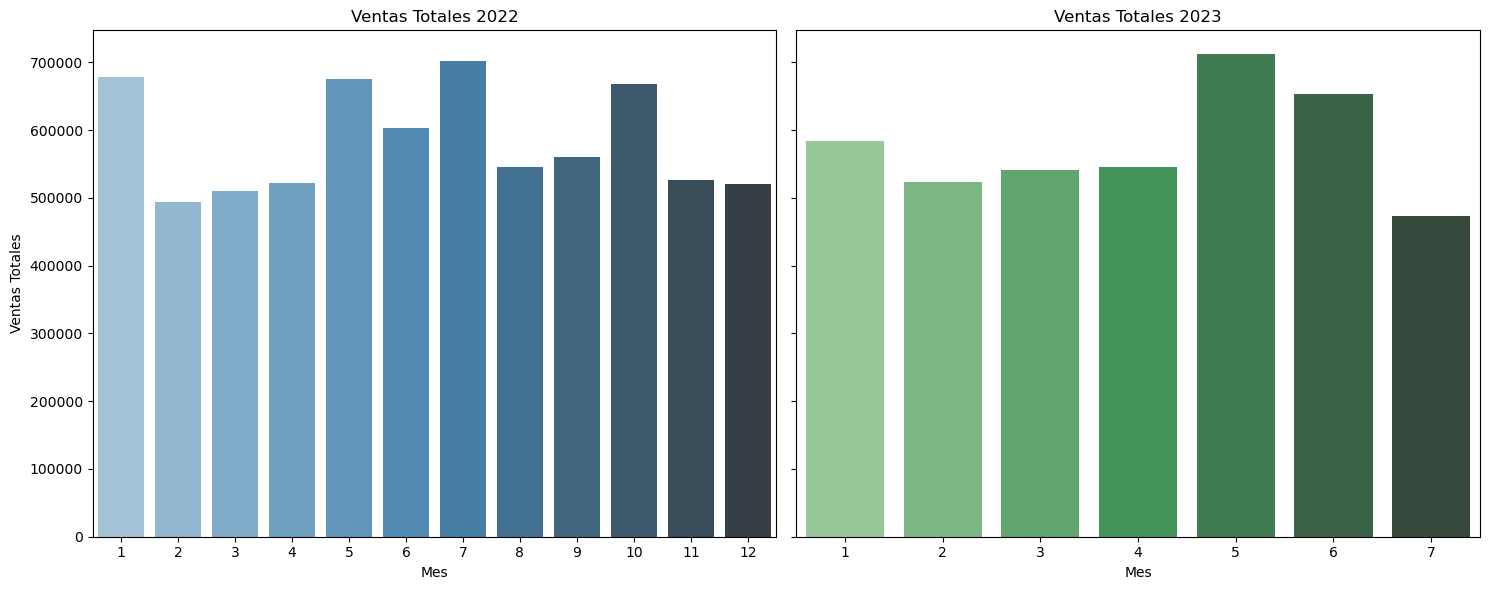

In [78]:
# Creamos primero una grafica que nos mustre si las ventas generales por mes dependiendo del año han aumnetado o disminuido
# Agrupar las ventas por MES y AÑO
ventas_por_mes_año = df.groupby(['AÑO', 'MES'])['VALORES VENTAS TOTALES'].sum().reset_index()

# Crear subplots: uno para cada año
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Filtrar las ventas del primer año
ventas_2022 = ventas_por_mes_año[ventas_por_mes_año['AÑO'] == 2022]
ventas_2023 = ventas_por_mes_año[ventas_por_mes_año['AÑO'] == 2023]

# Gráfico de barras para el año 2022
sns.barplot(x='MES', y='VALORES VENTAS TOTALES', data=ventas_2022, ax=axes[0], palette='Blues_d')
axes[0].set_title('Ventas Totales 2022')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Ventas Totales')

# Gráfico de barras para el año 2023
sns.barplot(x='MES', y='VALORES VENTAS TOTALES', data=ventas_2023, ax=axes[1], palette='Greens_d')
axes[1].set_title('Ventas Totales 2023')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Nota
### Podemos observar gracias a esta grafica de distribución de tiempo, que las mayores ventas se hacen durantes el verano, siendo los meses: Mayo, Junio y Julio los mas altos en cuanto a cantidad de ventas totales al mismo tiempo que observamos que durante los terminos de cada estación del año las ventas disminuyen, por lo cual podríamos esperar que para finales de 2023 las ventas disminuyan en comparación a los meses hasta donde tenemos información.   

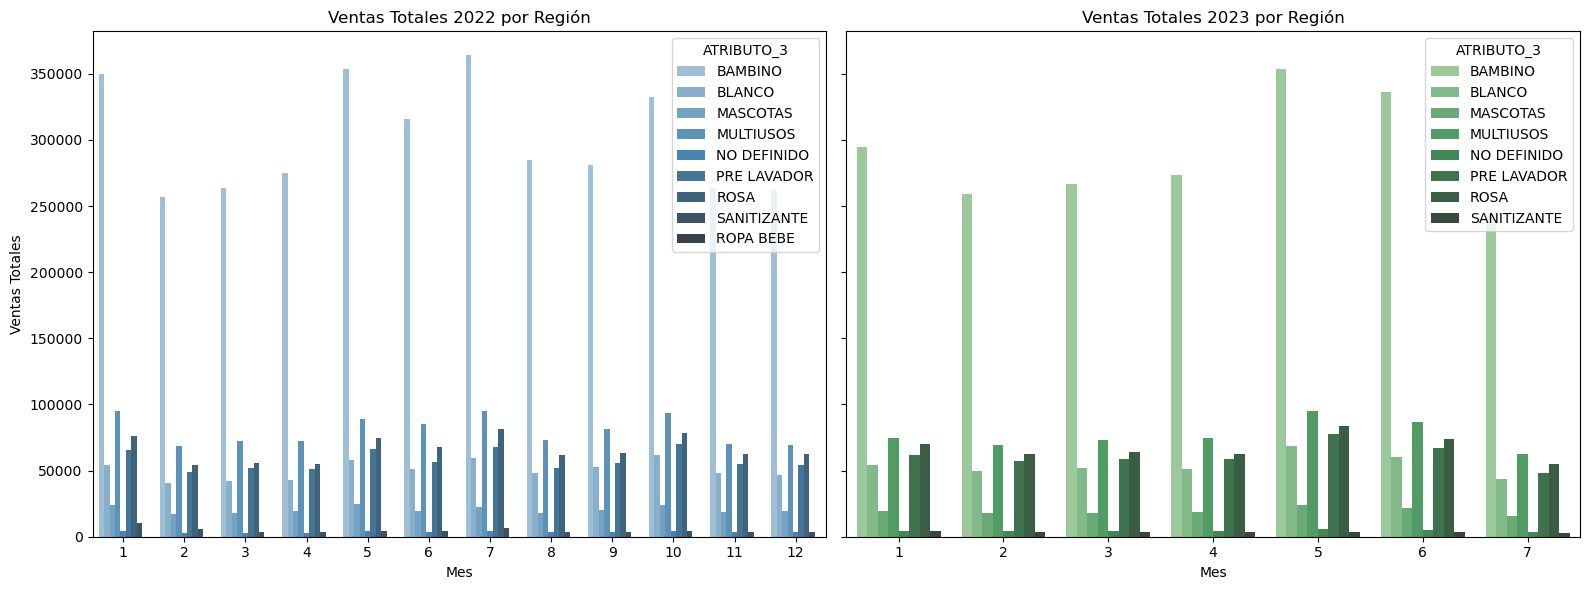

In [81]:
# Posteriormnete este grafico lo separamos por Productos o Atributos
# Agrupar las ventas por AÑO, MES y Atributos
ventas_por_mes_año_region = df.groupby(['AÑO', 'MES', 'ATRIBUTO_3'])['VALORES VENTAS TOTALES'].sum().reset_index()

# Crear subplots: uno para cada año
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Filtrar las ventas para 2022 y 2023
ventas_2022 = ventas_por_mes_año_region[ventas_por_mes_año_region['AÑO'] == 2022]
ventas_2023 = ventas_por_mes_año_region[ventas_por_mes_año_region['AÑO'] == 2023]

# Gráfico de barras para el año 2022, separado por región
sns.barplot(x='MES', y='VALORES VENTAS TOTALES', hue='ATRIBUTO_3', data=ventas_2022, ax=axes[0], palette='Blues_d')
axes[0].set_title('Ventas Totales 2022 por Región')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Ventas Totales')

# Gráfico de barras para el año 2023, separado por región
sns.barplot(x='MES', y='VALORES VENTAS TOTALES', hue='ATRIBUTO_3', data=ventas_2023, ax=axes[1], palette='Greens_d')
axes[1].set_title('Ventas Totales 2023 por Región')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Nota
### Al combinar la tabla de ventas totalesa lo largo del tiempo con las diferentes categorias existentes, podemos observar que ne base a la información que tenemos, la categoria "Bambino" es la que tiene más presencia en el mercvado por una gran diferencia y por el contrario, los productos destinados a ropa para bebe son los que menos ventas representan.

# Visualizar la distribución geográfica de las ventas

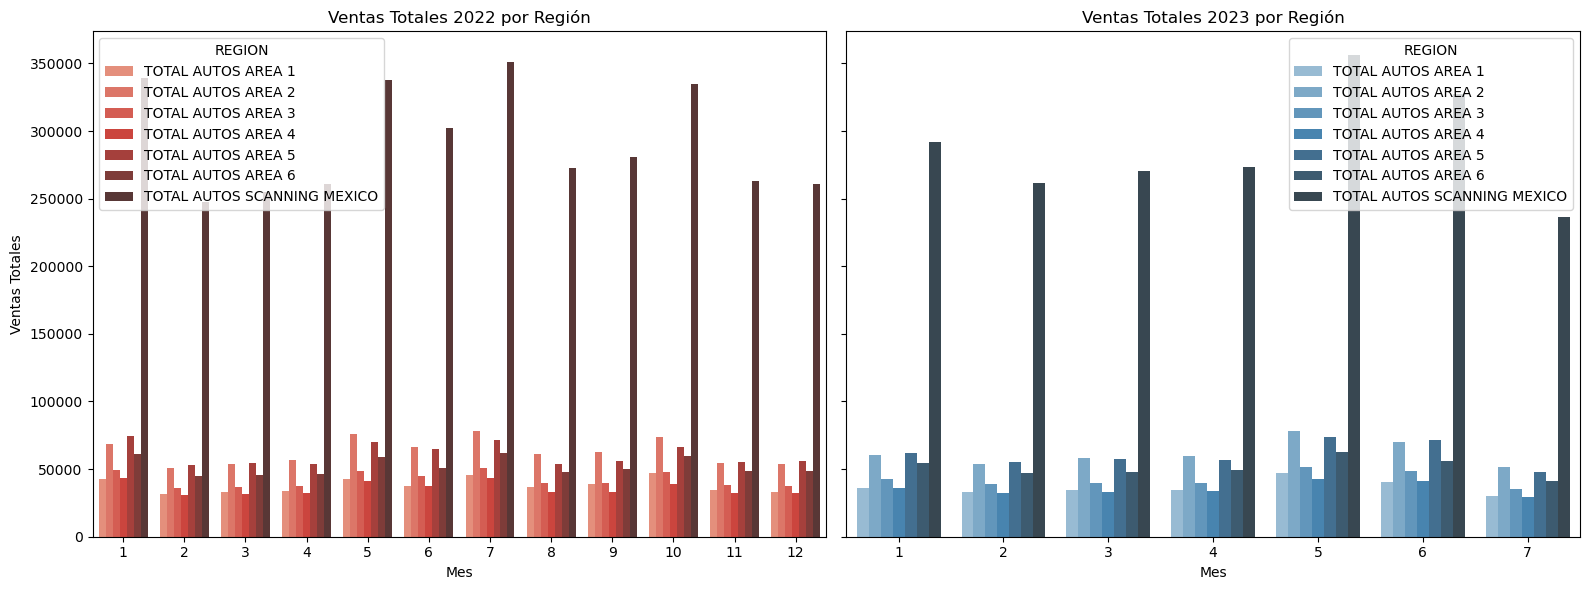

In [85]:
# Si es posible, utiliza mapas o gráficos de barras apiladas para visualizar las ventas por región. 
# Esto puede ayudar a identificar qué regiones tienen el mayor o menor rendimiento.

# Agrupar las ventas por AÑO, MES y REGION
ventas_por_mes_año_region = df.groupby(['AÑO', 'MES', 'REGION'])['VALORES VENTAS TOTALES'].sum().reset_index()

# Crear subplots: uno para cada año
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Filtrar las ventas para 2022 y 2023
ventas_2022 = ventas_por_mes_año_region[ventas_por_mes_año_region['AÑO'] == 2022]
ventas_2023 = ventas_por_mes_año_region[ventas_por_mes_año_region['AÑO'] == 2023]

# Gráfico de barras para el año 2022, separado por región
sns.barplot(x='MES', y='VALORES VENTAS TOTALES', hue='REGION', data=ventas_2022, ax=axes[0], palette='Reds_d')
axes[0].set_title('Ventas Totales 2022 por Región')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Ventas Totales')

# Gráfico de barras para el año 2023, separado por región
sns.barplot(x='MES', y='VALORES VENTAS TOTALES', hue='REGION', data=ventas_2023, ax=axes[1], palette='Blues_d')
axes[1].set_title('Ventas Totales 2023 por Región')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# NOTA
### Por ultimo, al unir la tabla de ventas totales con la tabla de región, podemos observar que la región que representa la mayor cantidad de ventas es "TOTAL AUTOS SCANNING MEXICO" y dentro de las mas bajas se encuentra "TOTAL AUTOS AREA 1" y "TOTAL AUTOS AREA 4"